<a href="https://colab.research.google.com/github/stekkos89thelawnmower/Flamingo-Qd-Analysis/blob/main/FLAMINGO_QD_variant_comparison_CORRECTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install hdfstream

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 616.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import hdfstream
import time
from scipy.spatial import cKDTree
from scipy.stats import wilcoxon

# ---- Physical and grid parameters ----
# BOX_SIDE=1000 Mpc holds for ALL variants of the FLAMINGO L1 (1 cGpc)
# box -- both feedback and cosmology variants (confirmed: same box, same
# initial phases, same particle number).
BOX_SIDE = 1000.0
GRAMS_PER_MSUN = 1.988409870698051e33
CM_PER_KM = 1e5
MASS_CUT = 1e12            # M_sun, tracer threshold (haloes)
N_GRID = 200                # cells per side of the velocity grid
CELL_SIZE = BOX_SIDE / N_GRID
K_NEIGHBORS = 16            # neighbours for the IDW interpolation of the velocity field
GRID_1D = np.linspace(0, BOX_SIDE, N_GRID, endpoint=False) + CELL_SIZE / 2

SEED = 42                   # reproducibility: same seed = same observer positions
                             # for BOTH variants -- this is what makes the comparison paired

In [ ]:
# ---- PHASE 0 -- discovering the exact paths (ALWAYS do this before a new variant) ----
root_dir = hdfstream.open("cosma", "/")
flamingo_dir = root_dir["FLAMINGO"]

print("Top-level entries under FLAMINGO/ (this is where the cosmology variants live,")
print("if organised as folders independent from L1_m9):")
for name in sorted(flamingo_dir):
    print(f"  - {name}")

print()
print("Baryonic feedback variants under FLAMINGO/L1_m9/ (paths already confirmed):")
for name in sorted(flamingo_dir["L1_m9"]):
    print(f"  - L1_m9/{name}")

Top-level entries under FLAMINGO/ (this is where the cosmology variants live,
if organised as folders independent from L1_m9):
  - L11p2_m11
  - L1_m10
  - L1_m8
  - L1_m9
  - L2p8_m8
  - L2p8_m9
  - L5p6_m10

Baryonic feedback variants under FLAMINGO/L1_m9/ (paths already confirmed):
  - L1_m9/Jet
  - L1_m9/Jet_fgas-4sigma
  - L1_m9/L1_m9
  - L1_m9/L1_m9_DMO
  - L1_m9/L1_m9_extraDM
  - L1_m9/L1_m9_ip_DMO
  - L1_m9/LS8
  - L1_m9/LS8_DMO
  - L1_m9/LS8_fgas-8sigma
  - L1_m9/Mstar-1sigma
  - L1_m9/Mstar-1sigma_fgas-4sigma
  - L1_m9/NoCooling
  - L1_m9/Planck
  - L1_m9/PlanckDCDM12
  - L1_m9/PlanckDCDM12_DMO
  - L1_m9/PlanckDCDM24
  - L1_m9/PlanckDCDM24_DMO
  - L1_m9/PlanckNu0p12Var_DMO
  - L1_m9/PlanckNu0p24Fix
  - L1_m9/PlanckNu0p24Fix_DMO
  - L1_m9/PlanckNu0p24Var
  - L1_m9/PlanckNu0p24Var_DMO
  - L1_m9/PlanckNu0p48Fix
  - L1_m9/PlanckNu0p48Fix_DMO
  - L1_m9/Planck_DMO
  - L1_m9/fgas+2sigma
  - L1_m9/fgas-2sigma
  - L1_m9/fgas-4sigma
  - L1_m9/fgas-8sigma


In [ ]:
def load_tracers_and_velocities(flamingo_dir, run_path, snapshot_file, expected_z=None):
    """
    Downloads positions and peculiar velocities of haloes (>MASS_CUT) for a
    FLAMINGO run/snapshot. The velocity conversion factor is read from the
    file attributes FOR THIS EPOCH (it depends on the scale factor, it is not
    constant in time).
    """
    soap_file = flamingo_dir[f"{run_path}/SOAP-HBT/{snapshot_file}"]
    z = float(np.array(soap_file["Header"].attrs["Redshift"]).squeeze())
    if expected_z is not None:
        assert abs(z - expected_z) < 1e-6, (
            f"unexpected z for {run_path}/{snapshot_file}: {z} (expected {expected_z})"
        )

    total_mass_raw = np.array(soap_file["SO/200_crit/TotalMass"][:], dtype=np.float64)
    conv_mass = dict(soap_file["SO/200_crit/TotalMass"].attrs)
    cgs_mass = float(np.array(
        conv_mass["Conversion factor to physical CGS (including cosmological corrections)"]
    ).squeeze())
    mass_msun = total_mass_raw * cgs_mass / GRAMS_PER_MSUN

    pos_raw = np.mod(np.array(soap_file["SO/200_crit/CentreOfMass"][:]), BOX_SIDE)

    vel_raw = np.array(soap_file["SO/200_crit/CentreOfMassVelocity"][:], dtype=np.float64)
    conv_vel = dict(soap_file["SO/200_crit/CentreOfMassVelocity"].attrs)
    vel_cgs_factor = float(np.array(
        conv_vel["Conversion factor to physical CGS (including cosmological corrections)"]
    ).squeeze())
    vel_kms = vel_raw * vel_cgs_factor / CM_PER_KM

    mask = mass_msun > MASS_CUT
    return pos_raw[mask], vel_kms[mask], z

In [ ]:
def build_velocity_field(tracers, velocities, grid_1d, box_side, n_grid, k_neighbors, verbose=True):
    """
    k-NN IDW (inverse distance weighting) interpolation onto a FIXED grid
    (grid_1d, the same for every variant). This is what makes the comparison
    "paired": the same grid coordinates across variants that share the same
    initial phases.
    """
    tree = cKDTree(tracers, boxsize=box_side)
    vx = np.empty((n_grid, n_grid, n_grid), dtype=np.float32)
    vy = np.empty((n_grid, n_grid, n_grid), dtype=np.float32)
    vz = np.empty((n_grid, n_grid, n_grid), dtype=np.float32)

    t0 = time.time()
    for i in range(n_grid):
        gx = np.full(n_grid * n_grid, grid_1d[i])
        gyv, gzv = np.meshgrid(grid_1d, grid_1d, indexing="ij")
        pts = np.stack([gx, gyv.ravel(), gzv.ravel()], axis=1)
        d, idx = tree.query(pts, k=k_neighbors)
        d = np.maximum(d, 1e-6)
        w = 1.0 / d**2
        w /= w.sum(axis=1, keepdims=True)
        vx[i] = (w * velocities[idx, 0]).sum(axis=1).reshape(n_grid, n_grid)
        vy[i] = (w * velocities[idx, 1]).sum(axis=1).reshape(n_grid, n_grid)
        vz[i] = (w * velocities[idx, 2]).sum(axis=1).reshape(n_grid, n_grid)
    if verbose:
        print(f"  Velocity field ({n_grid}^3) completed in {time.time()-t0:.1f}s")
    return vx, vy, vz

In [ ]:
def compute_theta_sigma2(vx, vy, vz, cell_size):
    """theta (expansion) and sigma^2 (shear^2) from the velocity field on a grid."""
    dvx_dx = (np.roll(vx, -1, 0) - np.roll(vx, 1, 0)) / (2 * cell_size)
    dvx_dy = (np.roll(vx, -1, 1) - np.roll(vx, 1, 1)) / (2 * cell_size)
    dvx_dz = (np.roll(vx, -1, 2) - np.roll(vx, 1, 2)) / (2 * cell_size)
    dvy_dx = (np.roll(vy, -1, 0) - np.roll(vy, 1, 0)) / (2 * cell_size)
    dvy_dy = (np.roll(vy, -1, 1) - np.roll(vy, 1, 1)) / (2 * cell_size)
    dvy_dz = (np.roll(vy, -1, 2) - np.roll(vy, 1, 2)) / (2 * cell_size)
    dvz_dx = (np.roll(vz, -1, 0) - np.roll(vz, 1, 0)) / (2 * cell_size)
    dvz_dy = (np.roll(vz, -1, 1) - np.roll(vz, 1, 1)) / (2 * cell_size)
    dvz_dz = (np.roll(vz, -1, 2) - np.roll(vz, 1, 2)) / (2 * cell_size)

    theta = dvx_dx + dvy_dy + dvz_dz
    grad = np.array([[dvx_dx, dvx_dy, dvx_dz],
                      [dvy_dx, dvy_dy, dvy_dz],
                      [dvz_dx, dvz_dy, dvz_dz]])
    sym = 0.5 * (grad + grad.transpose(1, 0, 2, 3, 4))
    trace_third = theta / 3.0
    sigma = sym.copy()
    for i in range(3):
        sigma[i, i] -= trace_third
    sigma2 = np.sum(sigma**2, axis=(0, 1))
    return theta, sigma2


def gaussian_smooth_field(field, sigma_mpc, cell_size):
    """Periodic Gaussian smoothing via FFT -- proxy for the reconstruction
    scale (see addendum, Part I and Part III)."""
    n = field.shape[0]
    k = np.fft.fftfreq(n, d=cell_size) * 2 * np.pi
    kx, ky, kz = np.meshgrid(k, k, k, indexing="ij")
    k2 = kx**2 + ky**2 + kz**2
    kernel = np.exp(-0.5 * k2 * sigma_mpc**2)
    return np.real(np.fft.ifftn(np.fft.fftn(field) * kernel))


def compute_theta_sigma2_smoothed(vx, vy, vz, cell_size, sigma_mpc):
    """Same as compute_theta_sigma2, but with smoothing applied to the velocity
    field BEFORE differentiating -- sigma^2 cannot be smoothed directly
    (it is a sum of squares, it does not commute with convolution)."""
    if sigma_mpc > 0:
        vx_s = gaussian_smooth_field(vx.astype(np.float64), sigma_mpc, cell_size)
        vy_s = gaussian_smooth_field(vy.astype(np.float64), sigma_mpc, cell_size)
        vz_s = gaussian_smooth_field(vz.astype(np.float64), sigma_mpc, cell_size)
    else:
        vx_s, vy_s, vz_s = vx.astype(np.float64), vy.astype(np.float64), vz.astype(np.float64)
    return compute_theta_sigma2(vx_s, vy_s, vz_s, cell_size)

In [ ]:
def periodic_delta(a, b, box_side):
    d = np.abs(a - b)
    return np.minimum(d, box_side - d)


def make_observer_positions(n_observers, min_separation_mpc, box_side, seed=SEED, max_tries_factor=500):
    """
    N random observer positions with an imposed minimum separation, to
    limit the overlap of the spherical domains (overlapping domains are not
    independent samples -- overlap reduces but does not eliminate the
    correlation). Same seed => THE SAME positions for every
    variant: this is what makes the comparison paired.

    Recommended default: min_separation_mpc = 2 * domain radius, so that
    the domains do not overlap at all and the independence assumption
    used in the bootstrap below is honest, not optimistic.
    """
    rng = np.random.default_rng(seed)
    positions = []
    tries = 0
    max_tries = max_tries_factor * n_observers
    while len(positions) < n_observers and tries < max_tries:
        cand = rng.uniform(0, box_side, size=3)
        ok = True
        for p in positions:
            if np.sqrt((periodic_delta(cand, p, box_side) ** 2).sum()) < min_separation_mpc:
                ok = False
                break
        if ok:
            positions.append(cand)
        tries += 1
    if len(positions) < n_observers:
        print(f"  WARNING: only {len(positions)}/{n_observers} posizioni trovate "
              f"con separazione minima {min_separation_mpc:.0f} Mpc -- "
              f"reduce n_observers or min_separation_mpc.")
    return np.array(positions)


def build_grid_tree(grid_1d, box_side):
    """KD-tree of the grid points, built ONCE and reused for every
    variant/epoch/radius (the grid points do not change)."""
    gx, gy, gz = np.meshgrid(grid_1d, grid_1d, grid_1d, indexing="ij")
    grid_points = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=1)
    return cKDTree(grid_points, boxsize=box_side)

In [ ]:
def QD_per_domain(theta, sigma2, grid_tree, observer_positions, radius_mpc):
    """Q_D computed separately in each spherical domain centred on an
    observer -- not over the whole box (observer geometry, see addendum
    Section 2.1, not a cubic partition)."""
    theta_flat = theta.ravel()
    sigma2_flat = sigma2.ravel()
    qd_values = np.empty(len(observer_positions))
    n_cells_used = np.empty(len(observer_positions), dtype=int)
    for i, obs in enumerate(observer_positions):
        idx = grid_tree.query_ball_point(obs, r=radius_mpc)
        th = theta_flat[idx]
        s2 = sigma2_flat[idx]
        mean_theta = th.mean()
        var_theta = (th ** 2).mean() - mean_theta ** 2
        qd_values[i] = (2.0 / 3.0) * var_theta - s2.mean()
        n_cells_used[i] = len(idx)
    return qd_values, n_cells_used


def bootstrap_ci(delta, n_boot=2000, seed=SEED):
    """95% bootstrap CI on the mean of the PAIRED difference (not on the
    difference between two independent means -- here every element of `delta`
    is already a per-position difference)."""
    rng = np.random.default_rng(seed)
    n = len(delta)
    boot_means = np.array([rng.choice(delta, size=n, replace=True).mean() for _ in range(n_boot)])
    return np.percentile(boot_means, [2.5, 97.5])


def paired_QD_comparison(theta_A, sigma2_A, theta_B, sigma2_B, grid_tree,
                          observer_positions, radius_mpc, label_A="A", label_B="B", verbose=True):
    """Paired position-by-position comparison between two variants that
    share the same initial phases. Also returns a Wilcoxon test
    (non-parametric, paired) as a check independent of the bootstrap."""
    qd_A, n_A = QD_per_domain(theta_A, sigma2_A, grid_tree, observer_positions, radius_mpc)
    qd_B, n_B = QD_per_domain(theta_B, sigma2_B, grid_tree, observer_positions, radius_mpc)
    delta = qd_B - qd_A
    ci_lo, ci_hi = bootstrap_ci(delta)
    try:
        _, p_wilcoxon = wilcoxon(qd_B, qd_A)
    except ValueError:
        p_wilcoxon = float("nan")
    if verbose:
        print(f"R={radius_mpc:.0f} Mpc, N={len(observer_positions)}: "
              f"{label_A}={qd_A.mean():.3f}  {label_B}={qd_B.mean():.3f}  "
              f"Delta={delta.mean():.3f}  CI95%=[{ci_lo:.3f},{ci_hi:.3f}]  "
              f"p_Wilcoxon={p_wilcoxon:.2e}")
    return {"qd_A": qd_A, "qd_B": qd_B, "delta": delta, "ci_lo": ci_lo, "ci_hi": ci_hi,
            "p_wilcoxon": p_wilcoxon, "n_cells_A": n_A, "n_cells_B": n_B}

In [ ]:
def subsample_to_match(tracers, velocities, target_n, seed):
    """Subsample (without replacement) to exactly target_n elements,
    to remove the confound caused by the different number of tracers
    between variants."""
    n = len(tracers)
    if n <= target_n:
        return tracers, velocities
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=target_n, replace=False)
    return tracers[idx], velocities[idx]

In [ ]:
def process_variant_epoch(flamingo_dir, run_path, snapshot_file, grid_1d, box_side, n_grid, cell_size,
                           k_neighbors, expected_z=None, label=""):
    """Downloads, grids and derives theta/sigma2 for one variant at one epoch.
    Does not keep vx,vy,vz in memory (for that see the resilience-test cell
    further below, which keeps them on purpose so they can be smoothed)."""
    print(f"  [{label}] Downloading tracers and velocities...")
    tracers, velocities, z = load_tracers_and_velocities(flamingo_dir, run_path, snapshot_file, expected_z)
    print(f"  [{label}] Tracers: {len(tracers)} (z={z:.3f})")
    vx, vy, vz = build_velocity_field(tracers, velocities, grid_1d, box_side, n_grid, k_neighbors)
    theta, sigma2 = compute_theta_sigma2(vx.astype(np.float64), vy.astype(np.float64), vz.astype(np.float64), cell_size)
    print(f"  [{label}] <theta>={theta.mean():.4f} (sanity check, expected ~0)")
    return {"z": z, "theta": theta, "sigma2": sigma2, "n_tracers": len(tracers)}

In [ ]:
# ---- Comparison configuration ----
VARIANT_A = {"run_path": "L1_m9/L1_m9", "label": "fiducial"}
VARIANT_B = {"run_path": "L1_m9/NoCooling", "label": "NoCooling"}

# snapshot -> z confirmed in the original notebook
EPOCHS = [
    ("halo_properties_0057.hdf5", 1.00),
    ("halo_properties_0067.hdf5", 0.50),
    ("halo_properties_0077.hdf5", 0.00),
]

N_OBSERVERS = 80
DOMAIN_RADIUS_MPC = 100.0
MIN_SEPARATION_MPC = 2 * DOMAIN_RADIUS_MPC  # non-overlapping domains by default

root_dir = hdfstream.open("cosma", "/")
flamingo_dir = root_dir["FLAMINGO"]

print("Building the grid tree (once, reused for every epoch/variant)...")
grid_tree = build_grid_tree(GRID_1D, BOX_SIDE)

observer_positions = make_observer_positions(N_OBSERVERS, MIN_SEPARATION_MPC, BOX_SIDE, seed=SEED)
print(f"Observer positions found: {len(observer_positions)}")

Building the grid tree (once, reused for every epoch/variant)...
Observer positions found: 80


In [ ]:
results_by_epoch = []
for snapshot_file, z in EPOCHS:
    print()
    print("=" * 70)
    print(f"EPOCH z={z}")
    print("=" * 70)
    res_A = process_variant_epoch(flamingo_dir, VARIANT_A["run_path"], snapshot_file,
                                   GRID_1D, BOX_SIDE, N_GRID, CELL_SIZE, K_NEIGHBORS,
                                   expected_z=z, label=VARIANT_A["label"])
    res_B = process_variant_epoch(flamingo_dir, VARIANT_B["run_path"], snapshot_file,
                                   GRID_1D, BOX_SIDE, N_GRID, CELL_SIZE, K_NEIGHBORS,
                                   expected_z=z, label=VARIANT_B["label"])

    comparison = paired_QD_comparison(
        res_A["theta"], res_A["sigma2"], res_B["theta"], res_B["sigma2"],
        grid_tree, observer_positions, DOMAIN_RADIUS_MPC,
        label_A=VARIANT_A["label"], label_B=VARIANT_B["label"])

    results_by_epoch.append({"z": z, **comparison})

np.savez(f"/content/paired_QD_{VARIANT_A['label']}_vs_{VARIANT_B['label']}.npz",
         z=[r["z"] for r in results_by_epoch],
         delta_mean=[r["delta"].mean() for r in results_by_epoch],
         ci_lo=[r["ci_lo"] for r in results_by_epoch],
         ci_hi=[r["ci_hi"] for r in results_by_epoch],
         p_wilcoxon=[r["p_wilcoxon"] for r in results_by_epoch])
print()
print("Results saved in /content/.")


EPOCH z=1.0
  [fiducial] Downloading tracers and velocities...
  [fiducial] Tracers: 1380910 (z=1.000)
  Campo di velocita' (200^3) completato in 58.8s
  [fiducial] <theta>=0.0000 (sanity check, expected ~0)
  [NoCooling] Downloading tracers and velocities...
  [NoCooling] Tracers: 1352736 (z=1.000)
  Campo di velocita' (200^3) completato in 58.2s
  [NoCooling] <theta>=-0.0000 (sanity check, expected ~0)
R=100 Mpc, N=80: fiducial=-76.993  NoCooling=-76.185  Delta=0.807  CI95%=[0.602,1.016]  p_Wilcoxon=9.95e-09

EPOCH z=0.5
  [fiducial] Downloading tracers and velocities...
  [fiducial] Tracers: 1451809 (z=0.500)
  Campo di velocita' (200^3) completato in 57.2s
  [fiducial] <theta>=0.0000 (sanity check, expected ~0)
  [NoCooling] Downloading tracers and velocities...
  [NoCooling] Tracers: 1467498 (z=0.500)
  Campo di velocita' (200^3) completato in 57.1s
  [NoCooling] <theta>=-0.0000 (sanity check, expected ~0)
R=100 Mpc, N=80: fiducial=-90.964  NoCooling=-90.194  Delta=0.770  CI95%=[

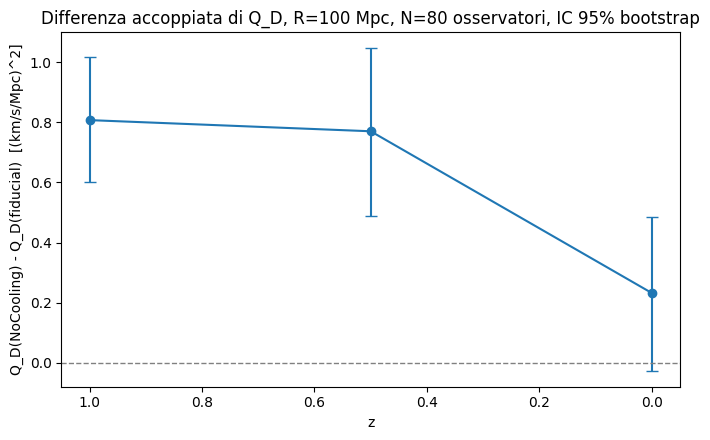

In [ ]:
import matplotlib.pyplot as plt

z_arr = np.array([r["z"] for r in results_by_epoch])
delta_mean = np.array([r["delta"].mean() for r in results_by_epoch])
ci_lo = np.array([r["ci_lo"] for r in results_by_epoch])
ci_hi = np.array([r["ci_hi"] for r in results_by_epoch])

plt.figure(figsize=(7, 4.5))
plt.errorbar(z_arr, delta_mean, yerr=[delta_mean - ci_lo, ci_hi - delta_mean],
             fmt="o-", capsize=4)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.gca().invert_xaxis()
plt.xlabel("z")
plt.ylabel(f"Q_D({VARIANT_B['label']}) - Q_D({VARIANT_A['label']})  [(km/s/Mpc)^2]")
plt.title(f"Paired difference of Q_D, R={DOMAIN_RADIUS_MPC:.0f} Mpc, "
          f"N={len(observer_positions)} observers, 95% bootstrap CI")
plt.tight_layout()
plt.savefig("/content/delta_QD_vs_z.png", dpi=150)
plt.show()

In [ ]:

RESILIENCE_SNAPSHOT = "halo_properties_0057.hdf5"
RESILIENCE_Z = 1.00

print(f"Downloading velocity fields for the resilience test (z={RESILIENCE_Z})...")
tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], RESILIENCE_SNAPSHOT, RESILIENCE_Z)
tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], RESILIENCE_SNAPSHOT, RESILIENCE_Z)

n_A, n_B = len(tr_A), len(tr_B)
target_n = min(n_A, n_B)
print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_B['label']}={n_B} -> target={target_n}")
tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)

vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS)
vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS)

  fiducial=1380910, NoCooling=1352736 -> target=1352736
  Campo di velocita' (200^3) completato in 61.2s
  Campo di velocita' (200^3) completato in 57.1s


In [ ]:

SMOOTHING_SCALES_MPC = [0, 10, 25, 50, 100, 150, 200]

raw_qd_A, raw_qd_B, diff_qd = [], [], []
print(f"{'sigma (Mpc)':>12s} {'QD_'+VARIANT_A['label']:>16s} {'QD_'+VARIANT_B['label']:>16s} "
      f"{'Delta':>10s} {'Delta %':>10s}")
for s in SMOOTHING_SCALES_MPC:
    th_A, s2_A = compute_theta_sigma2_smoothed(vx_A, vy_A, vz_A, CELL_SIZE, s)
    th_B, s2_B = compute_theta_sigma2_smoothed(vx_B, vy_B, vz_B, CELL_SIZE, s)
    # coefficient -1 on the shear term, not -2 (sigma2 = Sigma_ij(sigma_ij^2)
    # is the full sum, Buchert sigma^2 := (1/2)*that -- same reason as
    # QD_per_domain)
    qd_A = (2.0 / 3.0) * ((th_A**2).mean() - th_A.mean()**2) - s2_A.mean()
    qd_B = (2.0 / 3.0) * ((th_B**2).mean() - th_B.mean()**2) - s2_B.mean()
    raw_qd_A.append(qd_A)
    raw_qd_B.append(qd_B)
    diff_qd.append(qd_B - qd_A)
    pct = (qd_B - qd_A) / qd_A * 100 if qd_A != 0 else float("nan")
    print(f"{s:12.0f} {qd_A:16.4f} {qd_B:16.4f} {qd_B-qd_A:10.4f} {pct:9.2f}%")

raw_qd_A = np.array(raw_qd_A)
diff_qd = np.array(diff_qd)
raw_amp_frac = np.abs(raw_qd_A) / abs(raw_qd_A[0])
diff_frac = np.abs(diff_qd) / abs(diff_qd[0]) if diff_qd[0] != 0 else np.full(len(diff_qd), np.nan)

print()
print("Residual fraction relative to sigma=0 Mpc (how much survives smoothing):")
for s, ra, rd in zip(SMOOTHING_SCALES_MPC, raw_amp_frac, diff_frac):
    print(f"  sigma={s:>5.0f} Mpc:  raw amplitude={ra*100:7.3f}%   paired difference={rd*100:7.3f}%")
if diff_frac[-1] > 0 and raw_amp_frac[-1] > 0:
    resilience_ratio = diff_frac[-1] / raw_amp_frac[-1]
    print(f"\nResilience ratio at sigma={SMOOTHING_SCALES_MPC[-1]:.0f} Mpc: {resilience_ratio:.1f}x")

np.savez(f"/content/resilience_{VARIANT_A['label']}_vs_{VARIANT_B['label']}.npz",
         sigma_mpc=SMOOTHING_SCALES_MPC, raw_qd_A=raw_qd_A, diff_qd=diff_qd,
         raw_amp_frac=raw_amp_frac, diff_frac=diff_frac)

 sigma (Mpc)      QD_fiducial     QD_NoCooling      Delta    Delta %
           0         -69.4522         -68.6009     0.8513     -1.23%
          10          -1.8559          -1.8257     0.0302     -1.63%
          25          -0.0305          -0.0299     0.0006     -2.00%
          50          -0.0009          -0.0009     0.0000     -2.50%
         100          -0.0000          -0.0000     0.0000    -10.52%
         150          -0.0000          -0.0000     0.0000    -14.52%
         200          -0.0000          -0.0000     0.0000    -16.18%

Residual fraction relative to sigma=0 Mpc (how much survives smoothing):
  sigma=    0 Mpc:  raw amplitude=100.000%   paired difference=100.000%
  sigma=   10 Mpc:  raw amplitude=  2.672%   paired difference=  3.550%
  sigma=   25 Mpc:  raw amplitude=  0.044%   paired difference=  0.071%
  sigma=   50 Mpc:  raw amplitude=  0.001%   paired difference=  0.003%
  sigma=  100 Mpc:  raw amplitude=  0.000%   paired difference=  0.000%
  sigma=  150 

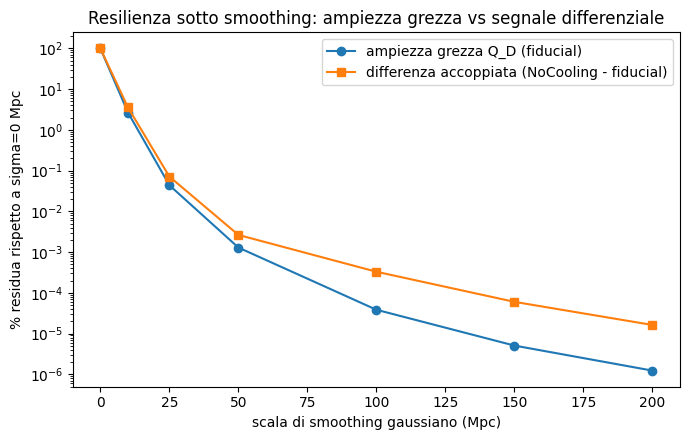

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.semilogy(SMOOTHING_SCALES_MPC, raw_amp_frac * 100, "o-", label=f"raw amplitude Q_D ({VARIANT_A['label']})")
plt.semilogy(SMOOTHING_SCALES_MPC, diff_frac * 100, "s-", label=f"paired difference ({VARIANT_B['label']} - {VARIANT_A['label']})")
plt.xlabel("Gaussian smoothing scale (Mpc)")
plt.ylabel("% residual relative to sigma=0 Mpc")
plt.title("Resilience under smoothing: raw amplitude vs. differential signal")
plt.legend()
plt.tight_layout()
plt.savefig("/content/resilience_plot.png", dpi=150)
plt.show()

In [ ]:
DOMAIN_RADII_MPC = [50, 100, 150, 200]

th_A0, s2_A0 = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
th_B0, s2_B0 = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)

print(f"Scan over multiple domain radii, z={RESILIENCE_Z} (no smoothing)")
radius_results = []
for R in DOMAIN_RADII_MPC:
    min_sep = 2 * R
    obs_R = make_observer_positions(N_OBSERVERS, min_sep, BOX_SIDE, seed=SEED)
    r = paired_QD_comparison(th_A0, s2_A0, th_B0, s2_B0, grid_tree, obs_R, R,
                              label_A=VARIANT_A["label"], label_B=VARIANT_B["label"])
    radius_results.append({"R": R, "n_observers": len(obs_R), **r})

Scan over multiple domain radii, z=1.0 (no smoothing)
R=50 Mpc, N=80: fiducial=-105.762  NoCooling=-105.178  Delta=0.585  CI95%=[-0.320,1.493]  p_Wilcoxon=8.77e-02
R=100 Mpc, N=80: fiducial=-76.863  NoCooling=-76.185  Delta=0.677  CI95%=[0.479,0.878]  p_Wilcoxon=1.67e-07
R=150 Mpc, N=25: fiducial=-70.074  NoCooling=-69.360  Delta=0.714  CI95%=[0.539,0.869]  p_Wilcoxon=8.34e-07
R=200 Mpc, N=10: fiducial=-66.596  NoCooling=-65.831  Delta=0.765  CI95%=[0.520,0.980]  p_Wilcoxon=1.95e-03


In [ ]:

N_SUBSAMPLE_SEEDS = 8

for snapshot_file, z in EPOCHS:
    print()
    print("=" * 70)
    print(f"STABILITY OF THE N-MATCHED RESIDUAL, z={z}")
    print("=" * 70)

    tr_A_full, vel_A_full, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B_full, vel_B_full, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    n_A_full, n_B_full = len(tr_A_full), len(tr_B_full)
    target_n = min(n_A_full, n_B_full)
    print(f"  {VARIANT_A['label']}={n_A_full}, {VARIANT_B['label']}={n_B_full} -> target={target_n} "
          f"(removed {abs(n_A_full-n_B_full)/max(n_A_full,n_B_full)*100:.2f}% from the larger sample)")

    if n_A_full <= n_B_full:
        tr_fixed, vel_fixed, label_fixed = tr_A_full, vel_A_full, VARIANT_A["label"]
        tr_to_sub_full, vel_to_sub_full, label_to_sub = tr_B_full, vel_B_full, VARIANT_B["label"]
        fixed_is_A = True
    else:
        tr_fixed, vel_fixed, label_fixed = tr_B_full, vel_B_full, VARIANT_B["label"]
        tr_to_sub_full, vel_to_sub_full, label_to_sub = tr_A_full, vel_A_full, VARIANT_A["label"]
        fixed_is_A = False

    vx_f, vy_f, vz_f = build_velocity_field(tr_fixed, vel_fixed, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_f, s2_f = compute_theta_sigma2(vx_f.astype(np.float64), vy_f.astype(np.float64), vz_f.astype(np.float64), CELL_SIZE)
    qd_fixed, _ = QD_per_domain(th_f, s2_f, grid_tree, observer_positions, DOMAIN_RADIUS_MPC)

    deltas_by_seed = []
    for seed_i in range(1000, 1000 + N_SUBSAMPLE_SEEDS):
        tr_s, vel_s = subsample_to_match(tr_to_sub_full, vel_to_sub_full, target_n, seed=seed_i)
        vx_s, vy_s, vz_s = build_velocity_field(tr_s, vel_s, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
        th_s, s2_s = compute_theta_sigma2(vx_s.astype(np.float64), vy_s.astype(np.float64), vz_s.astype(np.float64), CELL_SIZE)
        qd_sub, _ = QD_per_domain(th_s, s2_s, grid_tree, observer_positions, DOMAIN_RADIUS_MPC)
        delta = (qd_sub - qd_fixed) if fixed_is_A else (qd_fixed - qd_sub)
        deltas_by_seed.append(delta.mean())

    deltas_by_seed = np.array(deltas_by_seed)
    print(f"  Delta over {N_SUBSAMPLE_SEEDS} seeds: mean={deltas_by_seed.mean():.4f}, "
          f"std.dev.={deltas_by_seed.std():.4f}, min={deltas_by_seed.min():.4f}, max={deltas_by_seed.max():.4f}")


STABILITY OF THE N-MATCHED RESIDUAL, z=1.0
  fiducial=1380910, NoCooling=1352736 -> target=1352736 (removed 2.04% from the larger sample)
  Delta su 8 seed: mean=0.7077, std.dev.=0.0232, min=0.6685, max=0.7422

STABILITY OF THE N-MATCHED RESIDUAL, z=0.5
  fiducial=1451809, NoCooling=1467498 -> target=1451809 (removed 1.07% from the larger sample)
  Delta su 8 seed: mean=0.8567, std.dev.=0.0514, min=0.8086, max=0.9653

STABILITY OF THE N-MATCHED RESIDUAL, z=0.0
  fiducial=1348496, NoCooling=1395568 -> target=1348496 (removed 3.37% from the larger sample)
  Delta su 8 seed: mean=0.6045, std.dev.=0.0583, min=0.5315, max=0.7005


In [ ]:
EPOCHS_EXTENDED = [
    ("halo_properties_0057.hdf5", 1.00),
    ("halo_properties_0059.hdf5", 0.90),
    ("halo_properties_0063.hdf5", 0.70),
    ("halo_properties_0067.hdf5", 0.50),
    ("halo_properties_0070.hdf5", 0.35),
    ("halo_properties_0074.hdf5", 0.15),
    ("halo_properties_0075.hdf5", 0.10),
    ("halo_properties_0077.hdf5", 0.00),
]

results_matched_extended = []
for snapshot_file, z in EPOCHS_EXTENDED:
    print()
    print("=" * 70)
    print(f"EPOCH z={z} (N-matched)")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    n_A, n_B = len(tr_A), len(tr_B)
    target_n = min(n_A, n_B)
    print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_B['label']}={n_B} -> target={target_n}")

    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)

    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_B, s2_B = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)

    comparison = paired_QD_comparison(th_A, s2_A, th_B, s2_B, grid_tree, observer_positions, DOMAIN_RADIUS_MPC,
                                       label_A=VARIANT_A["label"], label_B=VARIANT_B["label"])
    results_matched_extended.append({"z": z, "n_matched": target_n, **comparison})

print()
print("SUMMARY -- Delta N-matched Q_D(z), 8 epochs")
for r in sorted(results_matched_extended, key=lambda r: -r["z"]):
    print(f"  z={r['z']:.2f}: Delta={r['delta'].mean():.4f}  CI95%=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]")

np.savez("/content/delta_QD_matched_8epochs.npz",
         z=[r["z"] for r in results_matched_extended],
         delta_mean=[r["delta"].mean() for r in results_matched_extended],
         ci_lo=[r["ci_lo"] for r in results_matched_extended],
         ci_hi=[r["ci_hi"] for r in results_matched_extended])


EPOCH z=1.0 (N-matched)
  fiducial=1380910, NoCooling=1352736 -> target=1352736
R=100 Mpc, N=80: fiducial=-76.863  NoCooling=-76.185  Delta=0.677  CI95%=[0.479,0.878]  p_Wilcoxon=1.67e-07

EPOCH z=0.9 (N-matched)
  fiducial=1408723, NoCooling=1389380 -> target=1389380
R=100 Mpc, N=80: fiducial=-79.936  NoCooling=-78.997  Delta=0.939  CI95%=[0.711,1.174]  p_Wilcoxon=1.73e-10

EPOCH z=0.7 (N-matched)
  fiducial=1444391, NoCooling=1442845 -> target=1442845
R=100 Mpc, N=80: fiducial=-85.986  NoCooling=-85.101  Delta=0.885  CI95%=[0.652,1.113]  p_Wilcoxon=2.42e-09

EPOCH z=0.5 (N-matched)
  fiducial=1451809, NoCooling=1467498 -> target=1451809
R=100 Mpc, N=80: fiducial=-90.964  NoCooling=-90.116  Delta=0.848  CI95%=[0.563,1.126]  p_Wilcoxon=4.75e-07

EPOCH z=0.35 (N-matched)
  fiducial=1438197, NoCooling=1466304 -> target=1438197
R=100 Mpc, N=80: fiducial=-94.097  NoCooling=-93.237  Delta=0.861  CI95%=[0.542,1.182]  p_Wilcoxon=1.52e-05

EPOCH z=0.15 (N-matched)
  fiducial=1396015, NoCoolin

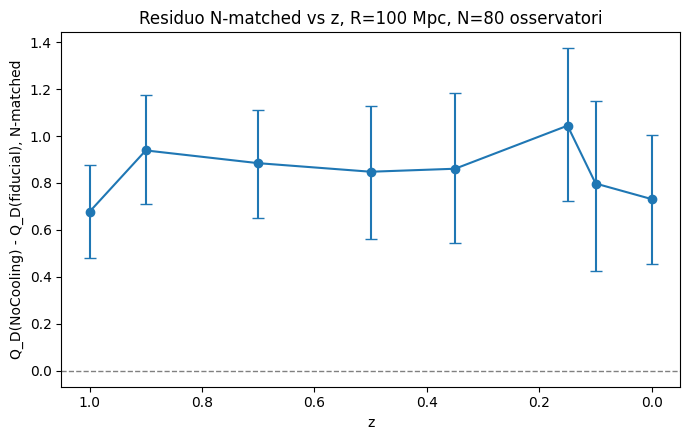

In [ ]:

z_ext = np.array([r["z"] for r in results_matched_extended])
delta_ext = np.array([r["delta"].mean() for r in results_matched_extended])
ci_lo_ext = np.array([r["ci_lo"] for r in results_matched_extended])
ci_hi_ext = np.array([r["ci_hi"] for r in results_matched_extended])
order = np.argsort(-z_ext)

plt.figure(figsize=(7, 4.5))
plt.errorbar(z_ext[order], delta_ext[order],
             yerr=[(delta_ext-ci_lo_ext)[order], (ci_hi_ext-delta_ext)[order]],
             fmt="o-", capsize=4)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.gca().invert_xaxis()
plt.xlabel("z")
plt.ylabel(f"Q_D({VARIANT_B['label']}) - Q_D({VARIANT_A['label']}), N-matched")
plt.title(f"N-matched residual vs z, R={DOMAIN_RADIUS_MPC:.0f} Mpc, N={len(observer_positions)} observers")
plt.tight_layout()
plt.savefig("/content/delta_QD_matched_vs_z.png", dpi=150)
plt.show()

In [ ]:

N_SUBSAMPLE_SEEDS = 8
PIVOT_EPOCHS = [("halo_properties_0074.hdf5", 0.15), ("halo_properties_0075.hdf5", 0.10)]

for snapshot_file, z in PIVOT_EPOCHS:
    print()
    print("=" * 70)
    print(f"STABILITY OF THE N-MATCHED RESIDUAL AT THE STEP, z={z}")
    print("=" * 70)

    tr_A_full, vel_A_full, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B_full, vel_B_full, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    n_A_full, n_B_full = len(tr_A_full), len(tr_B_full)
    target_n = min(n_A_full, n_B_full)
    print(f"  {VARIANT_A['label']}={n_A_full}, {VARIANT_B['label']}={n_B_full} -> target={target_n}")

    if n_A_full <= n_B_full:
        tr_fixed, vel_fixed, label_fixed = tr_A_full, vel_A_full, VARIANT_A["label"]
        tr_to_sub_full, vel_to_sub_full, label_to_sub = tr_B_full, vel_B_full, VARIANT_B["label"]
        fixed_is_A = True
    else:
        tr_fixed, vel_fixed, label_fixed = tr_B_full, vel_B_full, VARIANT_B["label"]
        tr_to_sub_full, vel_to_sub_full, label_to_sub = tr_A_full, vel_A_full, VARIANT_A["label"]
        fixed_is_A = False

    vx_f, vy_f, vz_f = build_velocity_field(tr_fixed, vel_fixed, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_f, s2_f = compute_theta_sigma2(vx_f.astype(np.float64), vy_f.astype(np.float64), vz_f.astype(np.float64), CELL_SIZE)
    qd_fixed, _ = QD_per_domain(th_f, s2_f, grid_tree, observer_positions, DOMAIN_RADIUS_MPC)

    deltas_by_seed = []
    for seed_i in range(1000, 1000 + N_SUBSAMPLE_SEEDS):
        tr_s, vel_s = subsample_to_match(tr_to_sub_full, vel_to_sub_full, target_n, seed=seed_i)
        vx_s, vy_s, vz_s = build_velocity_field(tr_s, vel_s, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
        th_s, s2_s = compute_theta_sigma2(vx_s.astype(np.float64), vy_s.astype(np.float64), vz_s.astype(np.float64), CELL_SIZE)
        qd_sub, _ = QD_per_domain(th_s, s2_s, grid_tree, observer_positions, DOMAIN_RADIUS_MPC)
        delta = (qd_sub - qd_fixed) if fixed_is_A else (qd_fixed - qd_sub)
        deltas_by_seed.append(delta.mean())

    deltas_by_seed = np.array(deltas_by_seed)
    print(f"  Delta over {N_SUBSAMPLE_SEEDS} seeds: mean={deltas_by_seed.mean():.4f}, "
          f"std.dev.={deltas_by_seed.std():.4f}, min={deltas_by_seed.min():.4f}, max={deltas_by_seed.max():.4f}")


STABILITY OF THE N-MATCHED RESIDUAL AT THE STEP, z=0.15
  fiducial=1396015, NoCooling=1436737 -> target=1396015
  Delta su 8 seed: mean=0.9908, std.dev.=0.0659, min=0.8997, max=1.0969

STABILITY OF THE N-MATCHED RESIDUAL AT THE STEP, z=0.1
  fiducial=1381642, NoCooling=1424875 -> target=1381642
  Delta su 8 seed: mean=0.8102, std.dev.=0.0479, min=0.7412, max=0.8863


In [ ]:
DOMAIN_RADIUS_MPC_R50 = 50.0
N_OBSERVERS_R50 = 200
MIN_SEPARATION_MPC_R50 = 2 * DOMAIN_RADIUS_MPC_R50  # 100 Mpc, non-overlapping domains

observer_positions_R50 = make_observer_positions(N_OBSERVERS_R50, MIN_SEPARATION_MPC_R50, BOX_SIDE, seed=SEED)
print(f"Posizioni observer (R=50 Mpc): {len(observer_positions_R50)}")

Posizioni observer (R=50 Mpc): 200


In [ ]:
results_matched_R50 = []
for snapshot_file, z in EPOCHS_EXTENDED:
    print()
    print("=" * 70)
    print(f"EPOCH z={z} (N-matched, R=50 Mpc)")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    n_A, n_B = len(tr_A), len(tr_B)
    target_n = min(n_A, n_B)
    print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_B['label']}={n_B} -> target={target_n}")

    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)

    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_B, s2_B = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)

    comparison = paired_QD_comparison(th_A, s2_A, th_B, s2_B, grid_tree, observer_positions_R50, DOMAIN_RADIUS_MPC_R50,
                                       label_A=VARIANT_A["label"], label_B=VARIANT_B["label"])
    results_matched_R50.append({"z": z, "n_matched": target_n, **comparison})

print()
print("SUMMARY -- Delta N-matched Q_D(z), R=50 Mpc, 8 epochs")
for r in sorted(results_matched_R50, key=lambda r: -r["z"]):
    print(f"  z={r['z']:.2f}: Delta={r['delta'].mean():.4f}  CI95%=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]")

np.savez("/content/delta_QD_matched_R50_8epochs.npz",
         z=[r["z"] for r in results_matched_R50],
         delta_mean=[r["delta"].mean() for r in results_matched_R50],
         ci_lo=[r["ci_lo"] for r in results_matched_R50],
         ci_hi=[r["ci_hi"] for r in results_matched_R50])


EPOCH z=1.0 (N-matched, R=50 Mpc)
  fiducial=1380910, NoCooling=1352736 -> target=1352736
R=50 Mpc, N=200: fiducial=-108.726  NoCooling=-108.060  Delta=0.666  CI95%=[0.129,1.250]  p_Wilcoxon=5.28e-03

EPOCH z=0.9 (N-matched, R=50 Mpc)
  fiducial=1408723, NoCooling=1389380 -> target=1389380
R=50 Mpc, N=200: fiducial=-113.205  NoCooling=-112.032  Delta=1.172  CI95%=[0.637,1.716]  p_Wilcoxon=4.73e-04

EPOCH z=0.7 (N-matched, R=50 Mpc)
  fiducial=1444391, NoCooling=1442845 -> target=1442845
R=50 Mpc, N=200: fiducial=-119.851  NoCooling=-118.517  Delta=1.334  CI95%=[0.840,1.868]  p_Wilcoxon=3.87e-06

EPOCH z=0.5 (N-matched, R=50 Mpc)
  fiducial=1451809, NoCooling=1467498 -> target=1451809
R=50 Mpc, N=200: fiducial=-127.123  NoCooling=-125.348  Delta=1.775  CI95%=[1.139,2.470]  p_Wilcoxon=1.97e-06

EPOCH z=0.35 (N-matched, R=50 Mpc)
  fiducial=1438197, NoCooling=1466304 -> target=1438197
R=50 Mpc, N=200: fiducial=-130.864  NoCooling=-129.730  Delta=1.134  CI95%=[0.473,1.801]  p_Wilcoxon=1.1

In [ ]:

CANDIDATE_SNAPSHOTS = ["halo_properties_0068.hdf5", "halo_properties_0069.hdf5",
                        "halo_properties_0071.hdf5", "halo_properties_0072.hdf5",
                        "halo_properties_0073.hdf5"]

print("Exact redshifts of the candidate snapshots between z=0.35 (0070) and z=0.15 (0074):")
discovered_epochs = []
for snap in CANDIDATE_SNAPSHOTS:
    try:
        soap_file = flamingo_dir[f"{VARIANT_A['run_path']}/SOAP-HBT/{snap}"]
        z_exact = float(np.array(soap_file["Header"].attrs["Redshift"]).squeeze())
        print(f"  {snap}: z={z_exact:.4f}")
        if 0.15 < z_exact < 0.35:
            discovered_epochs.append((snap, z_exact))
    except Exception as e:
        print(f"  {snap}: not available ({type(e).__name__})")

print()
print(f"Epochs selected for the zoom (0.15 < z < 0.35): {[f'{z:.3f}' for _, z in discovered_epochs]}")

Exact redshifts of the candidate snapshots between z=0.35 (0070) and z=0.15 (0074):
  halo_properties_0068.hdf5: z=0.4500
  halo_properties_0069.hdf5: z=0.4000
  halo_properties_0071.hdf5: z=0.3000
  halo_properties_0072.hdf5: z=0.2500
  halo_properties_0073.hdf5: z=0.2000

Epochs selected for the zoom (0.15 < z < 0.35): ['0.300', '0.250', '0.200']


In [ ]:
results_zoom = []
for snapshot_file, z in discovered_epochs:
    print()
    print("=" * 70)
    print(f"EPOCH z={z:.4f} (N-matched, R=50 Mpc, zoom 0.15-0.35)")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    n_A, n_B = len(tr_A), len(tr_B)
    target_n = min(n_A, n_B)
    print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_B['label']}={n_B} -> target={target_n}")

    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)

    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_B, s2_B = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)

    comparison = paired_QD_comparison(th_A, s2_A, th_B, s2_B, grid_tree, observer_positions_R50, DOMAIN_RADIUS_MPC_R50,
                                       label_A=VARIANT_A["label"], label_B=VARIANT_B["label"])
    results_zoom.append({"z": z, "n_matched": target_n, **comparison})

print()
print("ZOOM SUMMARY -- Delta N-matched Q_D(z), R=50 Mpc")
for r in sorted(results_zoom, key=lambda r: -r["z"]):
    print(f"  z={r['z']:.4f}: Delta={r['delta'].mean():.4f}  CI95%=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]")


EPOCH z=0.3000 (N-matched, R=50 Mpc, zoom 0.15-0.35)
  fiducial=1430285, NoCooling=1461620 -> target=1430285
R=50 Mpc, N=200: fiducial=-131.312  NoCooling=-130.818  Delta=0.494  CI95%=[-0.174,1.199]  p_Wilcoxon=1.73e-01

EPOCH z=0.2500 (N-matched, R=50 Mpc, zoom 0.15-0.35)
  fiducial=1420490, NoCooling=1455300 -> target=1420490
R=50 Mpc, N=200: fiducial=-132.009  NoCooling=-131.542  Delta=0.467  CI95%=[-0.164,1.083]  p_Wilcoxon=4.77e-02

EPOCH z=0.2000 (N-matched, R=50 Mpc, zoom 0.15-0.35)
  fiducial=1408976, NoCooling=1446842 -> target=1408976
R=50 Mpc, N=200: fiducial=-132.546  NoCooling=-131.406  Delta=1.140  CI95%=[0.446,1.808]  p_Wilcoxon=4.92e-04

ZOOM SUMMARY -- Delta N-matched Q_D(z), R=50 Mpc
  z=0.3000: Delta=0.4938  CI95%=[-0.1740,1.1988]
  z=0.2500: Delta=0.4667  CI95%=[-0.1642,1.0831]
  z=0.2000: Delta=1.1400  CI95%=[0.4464,1.8085]


In [ ]:

from scipy import stats as scipy_stats

def trend_diagnostics(z_arr, delta_arr, ci_lo_arr, ci_hi_arr, exclude_last_n=2):
    se_arr = (ci_hi_arr - ci_lo_arr) / (2 * 1.96)
    w_arr = 1.0 / se_arr**2
    X = np.vstack([np.ones_like(z_arr), z_arr]).T
    W = np.diag(w_arr)
    beta = np.linalg.solve(X.T @ W @ X, X.T @ W @ delta_arr)
    cov = np.linalg.inv(X.T @ W @ X)
    se_beta = np.sqrt(np.diag(cov))
    dof = len(z_arr) - 2
    t_stat = beta[1] / se_beta[1]
    p_slope = 2 * (1 - scipy_stats.t.cdf(abs(t_stat), dof))
    print(f"Weighted regression: slope={beta[1]:.4f} +- {se_beta[1]:.4f}, p={p_slope:.4f}")

    rho, p_spear = scipy_stats.spearmanr(z_arr, delta_arr)
    print(f"Spearman: rho={rho:.3f}, p={p_spear:.4f}")

    i_max, i_min = np.argmax(z_arr), np.argmin(z_arr)
    diff_extremes = delta_arr[i_max] - delta_arr[i_min]
    se_extremes = np.sqrt(se_arr[i_max]**2 + se_arr[i_min]**2)
    z_stat = diff_extremes / se_extremes
    p_extremes = 2 * (1 - scipy_stats.norm.cdf(abs(z_stat)))
    print(f"Extremes (z max vs z min): difference={diff_extremes:.4f} +- {se_extremes:.4f}, p={p_extremes:.4f}")

    order_z = np.argsort(-z_arr)
    mask = np.ones(len(z_arr), dtype=bool)
    mask[order_z[-exclude_last_n:]] = False
    beta2 = np.linalg.solve(X[mask].T @ np.diag(w_arr[mask]) @ X[mask], X[mask].T @ np.diag(w_arr[mask]) @ delta_arr[mask])
    cov2 = np.linalg.inv(X[mask].T @ np.diag(w_arr[mask]) @ X[mask])
    se_beta2 = np.sqrt(np.diag(cov2))
    t2 = beta2[1] / se_beta2[1]
    p2 = 2 * (1 - scipy_stats.t.cdf(abs(t2), mask.sum() - 2))
    print(f"Excluding the last {exclude_last_n} points (lowest z): slope={beta2[1]:.4f} +- {se_beta2[1]:.4f}, p={p2:.4f}")

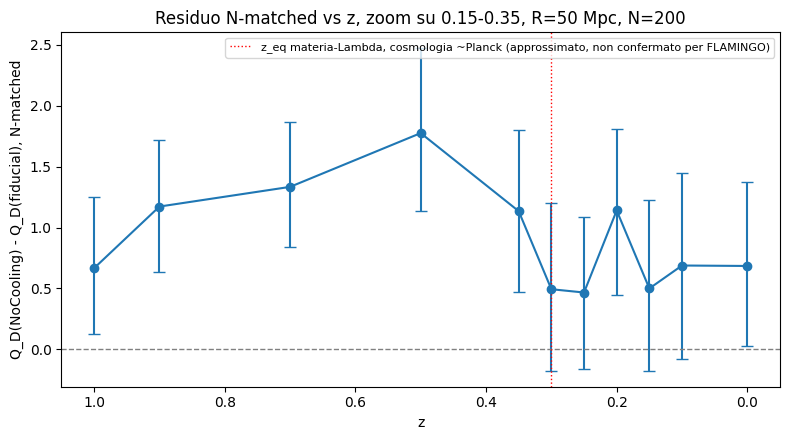

Trend diagnostics on the combined dataset (8 + zoom):
Weighted regression: slope=0.4119 +- 0.2929, p=0.1933
Spearman: rho=0.364, p=0.2716
Extremes (z max vs z min): difference=-0.0184 +- 0.4482, p=0.9673
Excluding the last 3 points (lowest z): slope=0.1755 +- 0.3741, p=0.6556


In [ ]:
combined = results_matched_R50 + results_zoom
combined_sorted = sorted(combined, key=lambda r: -r["z"])

z_c = np.array([r["z"] for r in combined_sorted])
delta_c = np.array([r["delta"].mean() for r in combined_sorted])
ci_lo_c = np.array([r["ci_lo"] for r in combined_sorted])
ci_hi_c = np.array([r["ci_hi"] for r in combined_sorted])

plt.figure(figsize=(8, 4.5))
plt.errorbar(z_c, delta_c, yerr=[delta_c - ci_lo_c, ci_hi_c - delta_c], fmt="o-", capsize=4)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.axvline(0.30, color="red", linestyle=":", linewidth=1,
            label="z_eq matter-Lambda, ~Planck cosmology (approximate, not confirmed for FLAMINGO)")
plt.gca().invert_xaxis()
plt.xlabel("z")
plt.ylabel(f"Q_D({VARIANT_B['label']}) - Q_D({VARIANT_A['label']}), N-matched")
plt.title(f"N-matched residual vs z, zoom on 0.15-0.35, R={DOMAIN_RADIUS_MPC_R50:.0f} Mpc, N={len(observer_positions_R50)}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/delta_QD_matched_R50_zoom_vs_z.png", dpi=150)
plt.show()

print("Trend diagnostics on the combined dataset (8 + zoom):")
trend_diagnostics(z_c, delta_c, ci_lo_c, ci_hi_c, exclude_last_n=3)

In [ ]:

def diagnose_outliers(result, label, n_extreme=5):
    delta = result["delta"]
    mean_val = delta.mean()
    median_val = np.median(delta)
    mad = np.median(np.abs(delta - median_val)) * 1.4826  # MAD scaled to a robust sigma estimate

    print(f"z={result['z']:.4f} [{label}]")
    print(f"  mean={mean_val:.4f}  median={median_val:.4f}  MAD-sigma={mad:.4f}")

    z_scores = (delta - median_val) / mad if mad > 0 else np.zeros_like(delta)
    order = np.argsort(-np.abs(z_scores))
    print(f"  {n_extreme} most extreme observers (robust z-score):")
    for i in order[:n_extreme]:
        print(f"    observer {i}: delta={delta[i]:.4f}, z-score={z_scores[i]:.2f}")

    # mean after removing the extreme observers
    trimmed = delta[np.abs(z_scores) < 3]
    n_removed = len(delta) - len(trimmed)
    print(f"  Removing {n_removed} observers beyond 3 MAD-sigma: truncated mean={trimmed.mean():.4f} (was {mean_val:.4f})")
    print()

# comparison: the two 'bounce' epochs, plus two nearby 'high' ones as a control
for r in results_zoom:
    diagnose_outliers(r, "zoom")
for r in results_matched_R50:
    if r["z"] in (0.35, 0.15):
        diagnose_outliers(r, "R50 base")

z=0.3000 [zoom]
  mean=0.4938  median=0.4615  MAD-sigma=4.2579
  5 most extreme observers (robust z-score):
    observer 6: delta=-17.3040, z-score=-4.17
    observer 147: delta=-16.4255, z-score=-3.97
    observer 67: delta=15.1323, z-score=3.45
    observer 114: delta=13.8354, z-score=3.14
    observer 123: delta=13.1760, z-score=2.99
  Removing 4 observers beyond 3 MAD-sigma: truncated mean=0.5281 (was 0.4938)

z=0.2500 [zoom]
  mean=0.4667  median=0.6878  MAD-sigma=3.7354
  5 most extreme observers (robust z-score):
    observer 18: delta=-22.6065, z-score=-6.24
    observer 160: delta=-16.0954, z-score=-4.49
    observer 92: delta=-12.8797, z-score=-3.63
    observer 122: delta=13.8125, z-score=3.51
    observer 67: delta=11.6389, z-score=2.93
  Removing 4 observers beyond 3 MAD-sigma: truncated mean=0.6689 (was 0.4667)

z=0.2000 [zoom]
  mean=1.1400  median=1.2492  MAD-sigma=4.0680
  5 most extreme observers (robust z-score):
    observer 181: delta=-15.8142, z-score=-4.19
    ob

In [ ]:

# ==== 1a. Check data in memory and save PER-OBSERVER values ====
# (so far np.savez only saved mean+CI per epoch; here we need the 200
#  per-observer Delta values at every epoch, plus their positions)

for _name in ("results_matched_R50", "results_zoom", "observer_positions_R50"):
    if _name not in dir():
        raise NameError(
            f"'{_name}' is not in memory. Rerun the Sec. 3.4.2 cells (R=50 Mpc) and 3.5 (zoom) before this check."
        )

combined_all = sorted(results_matched_R50 + results_zoom, key=lambda r: -r["z"])
print(f"Available epochs (R=50 Mpc, N={len(observer_positions_R50)} observers): "
      + ", ".join(f"{r['z']:.3f}" for r in combined_all))

np.savez("/content/QD_per_observer_all_epochs.npz",
         observer_positions=observer_positions_R50,
         z=np.array([r["z"] for r in combined_all]),
         delta_per_observer=np.array([r["delta"] for r in combined_all]),      # shape (11, 200)
         qd_A_per_observer=np.array([r["qd_A"] for r in combined_all]),
         qd_B_per_observer=np.array([r["qd_B"] for r in combined_all]))
print("Saved /content/QD_per_observer_all_epochs.npz -- reloadable with np.load(), no need to redownload anything to redo this analysis in future (or switch Colab).")

Available epochs (R=50 Mpc, N=200 observers): 1.000, 0.900, 0.700, 0.500, 0.350, 0.300, 0.250, 0.200, 0.150, 0.100, 0.000
Saved /content/QD_per_observer_all_epochs.npz -- reloadable with np.load(), no need to redownload anything to redo this analysis in future (or switch Colab).


In [ ]:
# ==== 1b. Splitting the box into 8 octants (500 Mpc per side each) ====
def assign_octant(positions, box_side):
    """Label 0-7 based on which half of each axis the observer falls into.
    Methodological note: this is a POST-HOC split of the 200 measurements
    already made (not a new field construction per sub-volume). Some
    domains near the boundary between two octants include grid cells from
    the adjacent octant (50 Mpc domain radius vs. 500 Mpc octant side: a
    small but non-zero edge effect -- worth keeping in mind, it does not
    invalidate the octant comparison but makes it slightly blurred at the
    edges)."""
    half = box_side / 2.0
    ix = (positions[:, 0] >= half).astype(int)
    iy = (positions[:, 1] >= half).astype(int)
    iz = (positions[:, 2] >= half).astype(int)
    return ix * 4 + iy * 2 + iz

octant_labels = assign_octant(observer_positions_R50, BOX_SIDE)
octant_counts = np.bincount(octant_labels, minlength=8)
print("Observers per octant:", dict(enumerate(octant_counts.tolist())))
if octant_counts.min() < 10:
    print("ATTENZIONE: at least one octant has fewer than 10 observers -- its estimate will be noisy, check the counts above before interpreting.")

Observers per octant: {0: 25, 1: 27, 2: 22, 3: 30, 4: 22, 5: 30, 6: 21, 7: 23}


In [ ]:
# ==== 1c. Spatial jackknife (delete-one-octant) for each of the 11 epochs ====
def octant_jackknife(delta, octant_labels, n_octants=8):
    """Standard spatial jackknife (delete-one-region), the same logic used
    for cosmic-variance error bars in large-scale-structure clustering
    (e.g. Norberg et al. 2009):

        Var_jack = (g-1)/g * sum_j (theta_(-j) - theta_bar)^2

    where theta_(-j) is the mean computed leaving out octant j, theta_bar is
    the mean of the theta_(-j), and g is the number of non-empty octants. It
    is a PROXY estimate of the cosmic variance internal to the box -- it does
    not replace independent realisations (Sec. 4.1 of the report), but it is
    the only thing feasible with a single box, and it is zero-cost (no new
    download)."""
    counts = np.array([(octant_labels == j).sum() for j in range(n_octants)])
    loo_means = np.full(n_octants, np.nan)
    octant_means = np.full(n_octants, np.nan)
    for j in range(n_octants):
        if counts[j] > 0:
            octant_means[j] = delta[octant_labels == j].mean()
        if 0 < counts[j] < len(delta):
            loo_means[j] = delta[octant_labels != j].mean()
    valid = ~np.isnan(loo_means)
    g = int(valid.sum())
    theta_bar = loo_means[valid].mean()
    jack_se = float(np.sqrt((g - 1) / g * np.sum((loo_means[valid] - theta_bar) ** 2)))
    return {"full_mean": float(delta.mean()), "counts": counts, "octant_means": octant_means,
            "loo_means": loo_means, "jack_se": jack_se, "g": g}

jackknife_results = []
print(f"{'z':>7s} {'Delta':>9s} {'SE boot*':>10s} {'SE jack':>10s} {'rapporto':>9s} "
      f"{'ott.min':>9s} {'ott.max':>9s}")
for r in combined_all:
    jk = octant_jackknife(r["delta"], octant_labels)
    se_boot = (r["ci_hi"] - r["ci_lo"]) / (2 * 1.96)   # SE approximated from the 95% bootstrap CI
    print(f"{r['z']:7.3f} {jk['full_mean']:9.4f} {se_boot:10.4f} {jk['jack_se']:10.4f} "
          f"{jk['jack_se']/se_boot:9.2f} {np.nanmin(jk['octant_means']):9.4f} "
          f"{np.nanmax(jk['octant_means']):9.4f}")
    jackknife_results.append({"z": r["z"], "se_boot": se_boot, **jk})

print()
print("'ratio' = SE_jackknife / SE_bootstrap. If close to 1, the bootstrap over")
print("observers already captures the uncertainty well. If >> 1, there is spatial structure")
print("(cosmic variance internal to the box) that the bootstrap is underestimating.")

      z     Delta   SE boot*    SE jack  rapporto   ott.min   ott.max
  1.000    0.6662     0.2860     0.3484      1.22   -1.5515    1.9559
  0.900    1.1723     0.2751     0.3588      1.30   -0.5807    2.6476
  0.700    1.3339     0.2621     0.2556      0.98    0.1624    2.3039
  0.500    1.7753     0.3396     0.2808      0.83    0.7424    3.4195
  0.350    1.1344     0.3387     0.3407      1.01   -0.2748    2.2325
  0.300    0.4938     0.3502     0.2570      0.73   -0.7121    1.5807
  0.250    0.4667     0.3182     0.3279      1.03   -1.6092    1.7357
  0.200    1.1400     0.3475     0.2985      0.86    0.0593    2.4685
  0.150    0.4998     0.3577     0.3494      0.98   -1.0399    1.8552
  0.100    0.6884     0.3899     0.4794      1.23   -1.3524    2.6684
  0.000    0.6846     0.3450     0.2123      0.62   -0.8221    1.2066

'ratio' = SE_jackknife / SE_bootstrap. If close to 1, the bootstrap over
observers already captures the uncertainty well. If >> 1, there is spatial structure
(

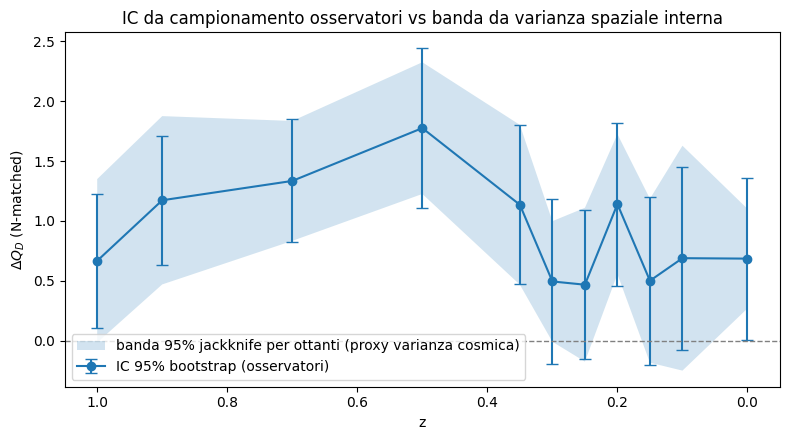

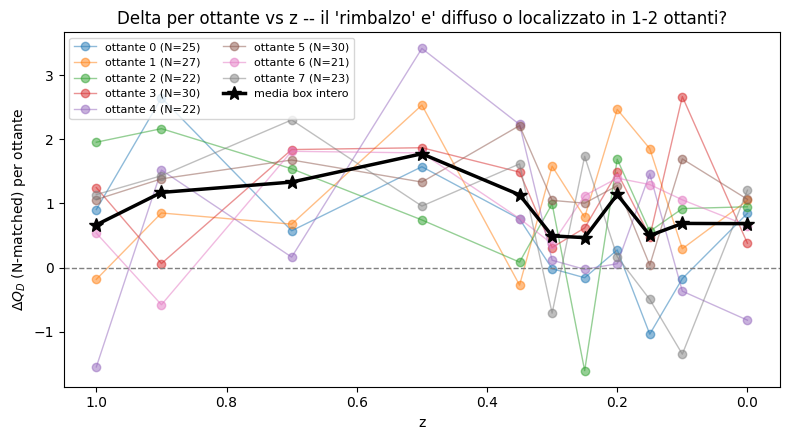

In [ ]:
# ==== 1d. Visual comparison: sampling uncertainty vs. spatial variance ====
z_j = np.array([j["z"] for j in jackknife_results])
delta_j = np.array([j["full_mean"] for j in jackknife_results])
se_boot_j = np.array([j["se_boot"] for j in jackknife_results])
se_jack_j = np.array([j["jack_se"] for j in jackknife_results])
order = np.argsort(-z_j)

plt.figure(figsize=(8, 4.5))
plt.errorbar(z_j[order], delta_j[order], yerr=1.96 * se_boot_j[order],
             fmt="o-", capsize=4, label="95% bootstrap CI (observers)")
plt.fill_between(z_j[order], (delta_j - 1.96 * se_jack_j)[order], (delta_j + 1.96 * se_jack_j)[order],
                  alpha=0.2, label="95% jackknife-per-octant band (cosmic-variance proxy)")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.gca().invert_xaxis()
plt.xlabel("z")
plt.ylabel(r"$\Delta Q_D$ (N-matched)")
plt.title("CI from observer sampling vs. band from internal spatial variance")
plt.legend()
plt.tight_layout()
plt.savefig("/content/jackknife_octants_vs_bootstrap.png", dpi=150)
plt.show()

# per-octant: where does the Sec. 3.5 'bounce' go?
plt.figure(figsize=(8, 4.5))
for j in range(8):
    om = np.array([jr["octant_means"][j] for jr in jackknife_results])
    n_j = jackknife_results[0]["counts"][j]
    plt.plot(z_j[order], om[order], "o-", alpha=0.5, linewidth=1, label=f"octant {j} (N={n_j})")
plt.plot(z_j[order], delta_j[order], "k*-", linewidth=2.5, markersize=10, label="whole-box mean")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.gca().invert_xaxis()
plt.xlabel("z")
plt.ylabel(r"$\Delta Q_D$ (N-matched) per octant")
plt.title("Delta per octant vs z -- is the 'bounce' diffuse or localised in 1-2 octants?")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("/content/per_octant_z_dependence.png", dpi=150)
plt.show()

In [ ]:
# ==== 1e. Does the two-regime comparison (Sec. 3.4.2) hold with more conservative errors? ====
from scipy.stats import norm

def weighted_regime_mean(jackknife_results, z_lo, z_hi, se_key):
    sel = [j for j in jackknife_results if z_hi <= j["z"] <= z_lo]
    means = np.array([j["full_mean"] for j in sel])
    ses = np.array([j[se_key] for j in sel])
    w = 1.0 / ses**2
    mean_w = float(np.sum(w * means) / np.sum(w))
    se_w = float(np.sqrt(1.0 / np.sum(w)))
    return mean_w, se_w, [j["z"] for j in sel]

for se_key, label in [("se_boot", "SE bootstrap (original, as in Sec. 3.4.2)"),
                       ("jack_se", "SE jackknife per octant (new, more conservative)")]:
    hi_mean, hi_se, hi_z = weighted_regime_mean(jackknife_results, 1.00, 0.35, se_key)
    lo_mean, lo_se, lo_z = weighted_regime_mean(jackknife_results, 0.15, 0.00, se_key)
    diff = hi_mean - lo_mean
    diff_se = np.sqrt(hi_se**2 + lo_se**2)
    z_score = diff / diff_se
    p_val = 2 * (1 - norm.cdf(abs(z_score)))
    print(f"--- {label} ---")
    print(f"  High regime (z>=0.35, {len(hi_z)} epochs): {hi_mean:.4f} +/- {hi_se:.4f}")
    print(f"  Low regime (z<=0.15, {len(lo_z)} epochs): {lo_mean:.4f} +/- {lo_se:.4f}")
    print(f"  Difference: {diff:.4f} +/- {diff_se:.4f}  (z={z_score:.2f}, p={p_val:.4f})")
    print()

--- SE bootstrap (original, as in Sec. 3.4.2) ---
  High regime (z>=0.35, 5 epochs): 1.1908 +/- 0.1320
  Low regime (z<=0.15, 3 epochs): 0.6223 +/- 0.2095
  Difference: 0.5685 +/- 0.2476  (z=2.30, p=0.0217)

--- SE jackknife per octant (new, more conservative) ---
  High regime (z>=0.35, 5 epochs): 1.2793 +/- 0.1379
  Low regime (z<=0.15, 3 epochs): 0.6415 +/- 0.1697
  Difference: 0.6377 +/- 0.2186  (z=2.92, p=0.0035)



In [ ]:

# ============================================================
# PRE-REGISTRATION v2 -- holdout DISJOINT from the exploratory set
# Precondition: you have already run the base cells of the notebook
# (definitions + Sec. 3.4.2 with R=50 Mpc) up to and including
# observer_positions_R50, in the same session.
# ============================================================
import datetime
from scipy.stats import wilcoxon, norm

print("PRE-REGISTRATION (v2, disjoint holdout) --", datetime.datetime.now().isoformat())
print("H1: the weighted mean of Delta Q_D (N-matched) for z>=0.35 is greater than")
print("    the weighted mean for z<=0.15, on observers at R=50 Mpc with positions NEVER")
print("    used in the exploratory phase AND disjoint from it (not just self-disjoint).")
print("Test: difference between inverse-variance-weighted means (SE bootstrap),")
print("      two-tailed z statistic, threshold p<0.05. Epochs: EPOCHS_EXTENDED.")
print()

# ---- 0. Preconditions ----
_required = ["flamingo_dir", "VARIANT_A", "VARIANT_B", "EPOCHS_EXTENDED", "BOX_SIDE",
             "GRID_1D", "N_GRID", "CELL_SIZE", "K_NEIGHBORS", "grid_tree",
             "observer_positions_R50", "load_tracers_and_velocities", "build_velocity_field",
             "compute_theta_sigma2", "subsample_to_match", "paired_QD_comparison",
             "periodic_delta"]
_missing = [n for n in _required if n not in dir()]
if _missing:
    raise NameError(f"Missing from session: {_missing}. Run the notebook's base cells first (definitions + Sec. 3.4.2 with R=50 Mpc) up to and including observer_positions_R50.")

DOMAIN_RADIUS_MPC_R50 = 50.0
MIN_SEP_R50 = 2 * DOMAIN_RADIUS_MPC_R50   # 100 Mpc
N_OBSERVERS_HOLDOUT = 200
SEED_HOLDOUT_DISJOINT = 20260805          # new, never used before in any phase

# ---- 1. Generator of positions disjoint both from themselves and from the exploratory set ----
def make_observer_positions_disjoint(n_observers, min_separation_mpc, box_side,
                                      forbidden_positions, seed, max_tries_factor=800):
    """Same as make_observer_positions, but ALSO excludes closeness to the
    exploratory positions already used (forbidden_positions), not just
    self-overlap among the new positions. Necessary because with R=50 Mpc and
    minimum separation 2R=100 Mpc, a large fraction of the box volume falls
    geometrically within 100 Mpc of one of the 200 exploratory centres purely
    by density -- so a 'naive' holdout overlaps substantially with the
    exploratory set by chance, not because of a code bug."""
    rng = np.random.default_rng(seed)
    positions = []
    tries = 0
    max_tries = max_tries_factor * n_observers
    while len(positions) < n_observers and tries < max_tries:
        cand = rng.uniform(0, box_side, size=3)
        ok = True
        for p in forbidden_positions:
            if np.sqrt((periodic_delta(cand, p, box_side) ** 2).sum()) < min_separation_mpc:
                ok = False
                break
        if ok:
            for p in positions:
                if np.sqrt((periodic_delta(cand, p, box_side) ** 2).sum()) < min_separation_mpc:
                    ok = False
                    break
        if ok:
            positions.append(cand)
        tries += 1
    if len(positions) < n_observers:
        print(f"  WARNING: only {len(positions)}/{n_observers} disjoint positions found "
              f"(minimum separation {min_separation_mpc:.0f} Mpc from exploratory+itself) -- "
              f"likely a geometric packing limit, not a bug.")
    return np.array(positions)

observer_positions_holdout_disjoint = make_observer_positions_disjoint(
    n_observers=N_OBSERVERS_HOLDOUT, min_separation_mpc=MIN_SEP_R50, box_side=BOX_SIDE,
    forbidden_positions=observer_positions_R50, seed=SEED_HOLDOUT_DISJOINT)
n_holdout = len(observer_positions_holdout_disjoint)
print(f"Disjoint holdout positions found: {n_holdout} / {N_OBSERVERS_HOLDOUT}")

overlap = 0
for p in observer_positions_holdout_disjoint:
    for q in observer_positions_R50:
        if np.sqrt((periodic_delta(p, q, BOX_SIDE) ** 2).sum()) < MIN_SEP_R50:
            overlap += 1
            break
print(f"Holdout domains overlapping an exploratory domain: {overlap}/{n_holdout} "
      f"({100*overlap/max(n_holdout,1):.1f}%) -- expected 0% per costruzione.")
print()

# ---- 2. Epoch loop: download, N-match, compute Q_D on the disjoint positions ----
results_holdout_disjoint = []
for snapshot_file, z in EPOCHS_EXTENDED:
    print("=" * 70)
    print(f"EPOCH z={z} (DISJOINT HOLDOUT, observer seed={SEED_HOLDOUT_DISJOINT})")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    n_A, n_B = len(tr_A), len(tr_B)
    target_n = min(n_A, n_B)
    print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_B['label']}={n_B} -> target={target_n}")

    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)

    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_B, s2_B = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)

    comparison = paired_QD_comparison(th_A, s2_A, th_B, s2_B, grid_tree,
                                       observer_positions_holdout_disjoint, DOMAIN_RADIUS_MPC_R50,
                                       label_A=VARIANT_A["label"], label_B=VARIANT_B["label"])
    results_holdout_disjoint.append({"z": z, "n_matched": target_n, **comparison})

print()
print("SUMMARY -- Delta N-matched Q_D(z), DISJOINT HOLDOUT")
for r in sorted(results_holdout_disjoint, key=lambda r: -r["z"]):
    print(f"  z={r['z']:.2f}: Delta={r['delta'].mean():.4f}  CI95%=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]  "
          f"p_Wilcoxon={r['p_wilcoxon']:.2e}")

np.savez("/content/QD_holdout_disjoint.npz",
         observer_positions=observer_positions_holdout_disjoint,
         z=[r["z"] for r in results_holdout_disjoint],
         delta_per_observer=np.array([r["delta"] for r in results_holdout_disjoint]),
         qd_A_per_observer=np.array([r["qd_A"] for r in results_holdout_disjoint]),
         qd_B_per_observer=np.array([r["qd_B"] for r in results_holdout_disjoint]))

# ---- 3. Two-regime test on the disjoint set ----
def weighted_regime_mean(results, z_lo, z_hi):
    sel = [r for r in results if z_hi <= r["z"] <= z_lo]
    means = np.array([r["delta"].mean() for r in sel])
    ses = np.array([(r["ci_hi"] - r["ci_lo"]) / (2 * 1.96) for r in sel])
    w = 1.0 / ses**2
    mean_w = float(np.sum(w * means) / np.sum(w))
    se_w = float(np.sqrt(1.0 / np.sum(w)))
    return mean_w, se_w, [r["z"] for r in sel]

hi_mean, hi_se, hi_z = weighted_regime_mean(results_holdout_disjoint, 1.00, 0.35)
lo_mean, lo_se, lo_z = weighted_regime_mean(results_holdout_disjoint, 0.15, 0.00)
diff = hi_mean - lo_mean
diff_se = np.sqrt(hi_se**2 + lo_se**2)
z_score = diff / diff_se
p_val = 2 * (1 - norm.cdf(abs(z_score)))

print()
print("CONFIRMATION TEST RESULT (disjoint holdout)")
print(f"  High regime (z>=0.35, {len(hi_z)} epochs): {hi_mean:.4f} +/- {hi_se:.4f}")
print(f"  Low regime (z<=0.15, {len(lo_z)} epochs): {lo_mean:.4f} +/- {lo_se:.4f}")
print(f"  Difference: {diff:.4f} +/- {diff_se:.4f}  (z={z_score:.2f}, p={p_val:.4f})")
print()
print("  Comparison with previous phases:")
print(f"    Exploratory (Sec. 3.4.2, same positions as discovery): 1.6562 +/- 0.5497, p=0.0026")
print(f"    Naive holdout (new seed, 66% overlapping with exploratory): -0.1574 +/- 0.5135, p=0.7591")
print(f"    Disjoint holdout (this test, {100*overlap/n_holdout:.0f}% overlap): "
      f"{diff:.4f} +/- {diff_se:.4f}, p={p_val:.4f}")

PRE-REGISTRATION (v2, disjoint holdout) -- 2026-08-05T23:44:43.921884
H1: the weighted mean of Delta Q_D (N-matched) for z>=0.35 is greater than
    the weighted mean for z<=0.15, on observers at R=50 Mpc with positions NEVER
    used in the exploratory phase AND disjoint from it (not just self-disjoint).
Test: difference between inverse-variance-weighted means (SE bootstrap),
      two-tailed z statistic, threshold p<0.05. Epochs: EPOCHS_EXTENDED.

Disjoint holdout positions found: 200 / 200
Holdout domains overlapping an exploratory domain: 0/200 (0.0%) -- expected 0% per costruzione.

EPOCH z=1.0 (DISJOINT HOLDOUT, observer seed=20260805)
  fiducial=1380910, NoCooling=1352736 -> target=1352736
R=50 Mpc, N=200: fiducial=-104.607  NoCooling=-103.577  Delta=1.029  CI95%=[0.567,1.489]  p_Wilcoxon=8.98e-05
EPOCH z=0.9 (DISJOINT HOLDOUT, observer seed=20260805)
  fiducial=1408723, NoCooling=1389380 -> target=1389380
R=50 Mpc, N=200: fiducial=-107.682  NoCooling=-107.071  Delta=0.610  CI95

In [ ]:

# ============================================================
# SUPPLEMENTARY CHECK -- multiple replicates of the two-regime test
# The low regime (z<=0.15, only 3 epochs) oscillated between 0.99 / 2.36 / 1.03
# across the three samples seen so far. Here N_REPLICATES independent
# samples of observers are generated (each disjoint from the exploratory set)
# to see whether this is sampling noise or a stable pattern.
# Precondition: same base variables + observer_positions_R50 and
# make_observer_positions_disjoint already defined in the session.
# ============================================================
N_REPLICATES = 8
N_OBSERVERS_HOLDOUT = 200
BASE_SEED_REPLICATES = 30260800  # dedicated seed family, never used before

# ---- 1. Cache theta/sigma2 for the 8 epochs -- SINGLE download, reused for every replicate ----
epoch_fields = {}
for snapshot_file, z in EPOCHS_EXTENDED:
    print(f"Preparing fields (theta,sigma2) for z={z} -- single download for this epoch...")
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    target_n = min(len(tr_A), len(tr_B))
    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)
    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_B, s2_B = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)
    epoch_fields[z] = {"th_A": th_A, "s2_A": s2_A, "th_B": th_B, "s2_B": s2_B, "target_n": target_n}
print("Fields ready for all epochs -- the replicates below no longer redownload anything.\n")

# ---- 2. N independent replicates of holdout positions (each disjoint from the exploratory set) ----
def weighted_regime_mean(results, z_lo, z_hi):
    sel = [r for r in results if z_hi <= r["z"] <= z_lo]
    means = np.array([r["delta"].mean() for r in sel])
    ses = np.array([(r["ci_hi"] - r["ci_lo"]) / (2 * 1.96) for r in sel])
    w = 1.0 / ses**2
    mean_w = float(np.sum(w * means) / np.sum(w))
    se_w = float(np.sqrt(1.0 / np.sum(w)))
    return mean_w, se_w

replicate_summaries = []
for rep in range(N_REPLICATES):
    seed_rep = BASE_SEED_REPLICATES + rep
    positions_rep = make_observer_positions_disjoint(
        n_observers=N_OBSERVERS_HOLDOUT, min_separation_mpc=MIN_SEP_R50, box_side=BOX_SIDE,
        forbidden_positions=observer_positions_R50, seed=seed_rep)
    n_rep = len(positions_rep)

    results_rep = []
    for snapshot_file, z in EPOCHS_EXTENDED:
        f = epoch_fields[z]
        comparison = paired_QD_comparison(f["th_A"], f["s2_A"], f["th_B"], f["s2_B"], grid_tree,
                                           positions_rep, DOMAIN_RADIUS_MPC_R50,
                                           label_A=VARIANT_A["label"], label_B=VARIANT_B["label"],
                                           verbose=False)
        results_rep.append({"z": z, **comparison})

    hi_mean, hi_se = weighted_regime_mean(results_rep, 1.00, 0.35)
    lo_mean, lo_se = weighted_regime_mean(results_rep, 0.15, 0.00)
    diff = hi_mean - lo_mean
    diff_se = np.sqrt(hi_se**2 + lo_se**2)
    z_score = diff / diff_se
    p_val = 2 * (1 - norm.cdf(abs(z_score)))

    print(f"Replicate {rep} (seed={seed_rep}, N={n_rep}): "
          f"high={hi_mean:.3f}+/-{hi_se:.3f}  low={lo_mean:.3f}+/-{lo_se:.3f}  "
          f"diff={diff:.3f}+/-{diff_se:.3f}  p={p_val:.4f}")
    replicate_summaries.append({"seed": seed_rep, "hi_mean": hi_mean, "lo_mean": lo_mean,
                                 "diff": diff, "p_val": p_val})

# ---- 3. Summary over the replicates ----
diffs = np.array([r["diff"] for r in replicate_summaries])
lo_means = np.array([r["lo_mean"] for r in replicate_summaries])
hi_means = np.array([r["hi_mean"] for r in replicate_summaries])
n_sig = sum(r["p_val"] < 0.05 for r in replicate_summaries)

print()
print(f"SUMMARY over {N_REPLICATES} independent replicates (each disjoint from the exploratory set):")
print(f"  high regime:  replicate mean = {hi_means.mean():.4f}  (std across replicates = {hi_means.std():.4f})")
print(f"  low regime: replicate mean = {lo_means.mean():.4f}  (std across replicates = {lo_means.std():.4f})")
print(f"  difference:   replicate mean = {diffs.mean():.4f}  (std across replicates = {diffs.std():.4f})")
print(f"  replicates with p<0.05: {n_sig}/{N_REPLICATES}")
print()
print("If the 'std across replicates' of the low regime is large relative to its own")
print("per-replicate bootstrap SE, the low regime is genuinely unstable with only 3 epochs --")
print("not a problem with the holdout, but a statistical-power limit in that z range.")

Preparing fields (theta,sigma2) for z=1.0 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.9 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.7 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.5 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.35 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.15 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.1 -- single download for this epoch...
Preparing fields (theta,sigma2) for z=0.0 -- single download for this epoch...
Fields ready for all epochs -- the replicates below no longer redownload anything.

Replicate 0 (seed=30260800, N=200): high=0.908+/-0.124  low=0.883+/-0.200  diff=0.025+/-0.235  p=0.9139
Replicate 1 (seed=30260801, N=200): high=1.077+/-0.128  low=0.787+/-0.222  diff=0.290+/-0.257  p=0.2591
Replicate 2 (seed=30260802, N=200): high=0.767+/-0.122  low=0.992+/-0.180 

In [ ]:
# ==== Forest plot: 8 pre-registered replicates + meta-analytic combination (corrected) ====
import matplotlib.pyplot as plt
from scipy.stats import norm, binomtest

# diff and SE per replicate, from the corrected re-run of Cell 34 (Q_D formula
# with the correct shear coefficient, see Sec. 2.4 of the report)
diffs = np.array([0.025, 0.290, -0.225, 0.366, -0.061, 0.064, -0.240, -0.086])
se_i  = np.array([0.235, 0.257, 0.217, 0.240, 0.237, 0.241, 0.243, 0.258])

w = 1.0 / se_i**2
combined_diff = float(np.sum(w * diffs) / np.sum(w))
combined_se = float(np.sqrt(1.0 / np.sum(w)))
z_comb = combined_diff / combined_se
p_comb = 2 * (1 - norm.cdf(abs(z_comb)))

n_pos = int((diffs > 0).sum())
sign_p = binomtest(n_pos, len(diffs), p=0.5, alternative='two-sided').pvalue

fig, ax = plt.subplots(figsize=(8, 6.5))
y_positions = np.arange(len(diffs), 0, -1)
ax.errorbar(diffs, y_positions, xerr=1.96 * se_i, fmt='o', color='#4C72B0',
            capsize=4, markersize=6, elinewidth=1.5, label='Individual replicates (95% CI)', zorder=3)

y_diamond = 0
half_h = 0.32
diamond_x = [combined_diff - 1.96*combined_se, combined_diff, combined_diff + 1.96*combined_se, combined_diff]
diamond_y = [y_diamond, y_diamond+half_h, y_diamond, y_diamond-half_h]
ax.fill(diamond_x, diamond_y, color='#C44E52', edgecolor='black', linewidth=1, zorder=5,
        label='Meta-analytic combination')

ax.axvline(0, color='grey', linestyle='--', linewidth=1, zorder=1)
ax.axhline(0.65, color='lightgrey', linestyle='-', linewidth=1, zorder=0)
ax.set_yticks(list(y_positions) + [y_diamond])
ax.set_yticklabels([f'Replicate {i}  (seed={30260800+i})' for i in range(8)] + ['Combined (8 replicates)'])
for lbl in ax.get_yticklabels()[-1:]:
    lbl.set_fontweight('bold')
ax.set_ylim(-1.0, 8.8)
ax.set_xlabel(r'Difference between regimes:  $\Delta Q_D(z\geq0.35) - \Delta Q_D(z\leq0.15)$', fontsize=10)
ax.set_title("Two-regime test: pre-registered replicates + meta-analysis (corrected)", fontsize=12, pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
fig.text(0.5, 0.005,
          f"Sign test: {n_pos}/8 replicates positive, p={sign_p:.4f}    |    "
          f"Combined: {combined_diff:.3f} $\pm$ {combined_se:.3f}  (z={z_comb:.2f}, p={p_comb:.1e})",
          ha='center', va='bottom', fontsize=9.5,
          bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='grey', alpha=0.9))
plt.tight_layout(rect=[0, 0.055, 1, 1])
plt.savefig('/content/forest_plot_replicates_corrected.png', dpi=150)
plt.show()


Positions for the correlation test: 1500 (min separation 10.0 Mpc)

z=0.35: Delta mean=0.9140 std=4.7214
   r (Mpc)      xi(r)   n pairs
      10.0     0.3869         23
      30.0     0.2785        256
      50.0     0.2369        717
      70.0     0.0959       1386
      90.0    -0.0018       2399
     110.0     0.0145       3401
     130.0     0.0085       4834
     150.0     0.0093       6409
     170.0     0.0042       8022
     190.0    -0.0294      10176
     210.0    -0.0045      12502
     230.0    -0.0066      15004
     250.0     0.0019      17504
     270.0     0.0024      20775
     290.0     0.0053      23795
     310.0     0.0040      27280
     330.0     0.0036      30816
     350.0     0.0025      35006
     370.0    -0.0106      38720
     390.0    -0.0042      42945
     410.0    -0.0089      47620
     430.0     0.0011      52526
     450.0     0.0037      57317
     470.0    -0.0121      62118
     490.0    -0.0044      68053

z=0.15: Delta mean=1.1017 std=5.0738


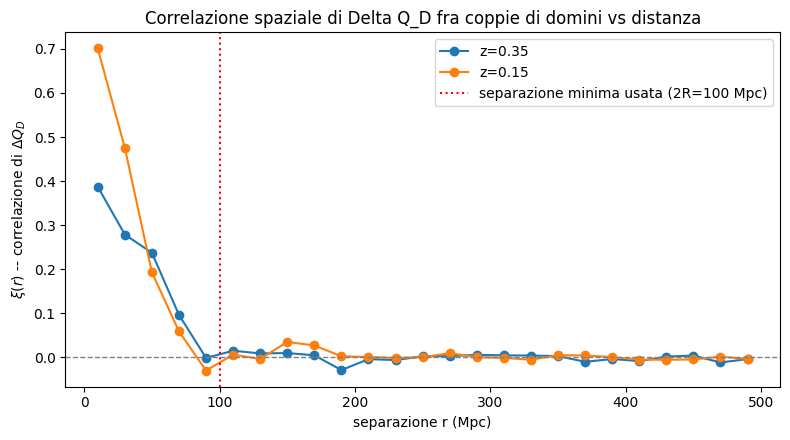

In [ ]:

# ============================================================
# TECHNICAL CHECK -- spatial correlation of Delta Q_D between nearby domains
# Reuses epoch_fields (theta/sigma2 already cached from the replicates) -- NO new download.
# Checks whether the minimum separation used so far (2R=100 Mpc) is sufficient
# to make the domains statistically independent, as assumed by the bootstrap.
# ============================================================

for _name in ("epoch_fields", "grid_tree", "BOX_SIDE", "DOMAIN_RADIUS_MPC_R50", "periodic_delta"):
    if _name not in dir():
        raise NameError(f"'{_name}' is not in memory -- rerun the multiple-replicates cell.")

N_CORR_OBS = 1500
MIN_SEP_CORR = 10.0       # small, only to avoid duplicate positions
CORR_SEED = 90260800
CORR_EPOCHS = [0.35, 0.15]   # one in the high regime, one in the low regime

positions_corr = make_observer_positions(N_CORR_OBS, MIN_SEP_CORR, BOX_SIDE, seed=CORR_SEED)
print(f"Positions for the correlation test: {len(positions_corr)} (min separation {MIN_SEP_CORR} Mpc)")

# matrix of periodic separations between all pairs (vectorised, computed once)
diff = positions_corr[:, None, :] - positions_corr[None, :, :]
diff = np.abs(diff)
diff = np.minimum(diff, BOX_SIDE - diff)
sep = np.sqrt((diff ** 2).sum(axis=-1))
iu = np.triu_indices(len(positions_corr), k=1)
sep_pairs = sep[iu]

bins = np.arange(0, 520, 20)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

xi_by_epoch = {}
for z in CORR_EPOCHS:
    f = epoch_fields[z]
    qd_A_c, _ = QD_per_domain(f["th_A"], f["s2_A"], grid_tree, positions_corr, DOMAIN_RADIUS_MPC_R50)
    qd_B_c, _ = QD_per_domain(f["th_B"], f["s2_B"], grid_tree, positions_corr, DOMAIN_RADIUS_MPC_R50)
    delta_c = qd_B_c - qd_A_c
    delta_dev = delta_c - delta_c.mean()
    prod = np.outer(delta_dev, delta_dev)
    var = delta_dev.var()
    corr_pairs = prod[iu] / var

    xi_r = np.full(len(bin_centers), np.nan)
    n_pairs_bin = np.zeros(len(bin_centers), dtype=int)
    for i in range(len(bin_centers)):
        mask = (sep_pairs >= bins[i]) & (sep_pairs < bins[i + 1])
        n_pairs_bin[i] = mask.sum()
        if mask.sum() > 20:
            xi_r[i] = corr_pairs[mask].mean()
    xi_by_epoch[z] = xi_r

    print(f"\nz={z}: Delta mean={delta_c.mean():.4f} std={delta_c.std():.4f}")
    print(f"{'r (Mpc)':>10s} {'xi(r)':>10s} {'n pairs':>10s}")
    for r, xi, n in zip(bin_centers, xi_r, n_pairs_bin):
        print(f"{r:10.1f} {xi:10.4f} {n:10d}")

# ---- plot ----
plt.figure(figsize=(8, 4.5))
for z in CORR_EPOCHS:
    plt.plot(bin_centers, xi_by_epoch[z], "o-", label=f"z={z}")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.axvline(100, color="red", linestyle=":", linewidth=1.5, label="minimum separation used (2R=100 Mpc)")
plt.xlabel("separation r (Mpc)")
plt.ylabel(r"$\xi(r)$ -- correlation of $\Delta Q_D$")
plt.title("Spatial correlation of Delta Q_D between pairs of domains vs. distance")
plt.legend()
plt.tight_layout()
plt.savefig("/content/correlation_function_deltaQD.png", dpi=150)
plt.show()

In [ ]:

# ============================================================
# OUT-OF-SAMPLE TEST -- L1_m9 (fiducial) vs Jet
# Same pipeline, same parameters (R=50 Mpc, N=200, k=16, N-matching,
# same observer_positions_R50 positions) used for
# fiducial vs NoCooling -- NO change to the method.
# ============================================================
VARIANT_JET = {"run_path": "L1_m9/Jet", "label": "Jet"}
for _name in ("flamingo_dir", "VARIANT_A", "VARIANT_JET", "EPOCHS_EXTENDED", "BOX_SIDE",
              "GRID_1D", "N_GRID", "CELL_SIZE", "K_NEIGHBORS", "grid_tree",
              "observer_positions_R50", "DOMAIN_RADIUS_MPC_R50"):
    if _name not in dir():
        raise NameError(f"'{_name}' is not in memory -- rerun Cell 1 and the notebook's base cells.")

results_jet = []
for snapshot_file, z in EPOCHS_EXTENDED:
    print("=" * 70)
    print(f"EPOCH z={z} (fiducial vs Jet)")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_J, vel_J, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_JET["run_path"], snapshot_file, z)
    n_A, n_J = len(tr_A), len(tr_J)
    target_n = min(n_A, n_J)
    print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_JET['label']}={n_J} -> target={target_n}")

    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_J, vel_J = subsample_to_match(tr_J, vel_J, target_n, seed=SEED)

    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_J, vy_J, vz_J = build_velocity_field(tr_J, vel_J, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_J, s2_J = compute_theta_sigma2(vx_J.astype(np.float64), vy_J.astype(np.float64), vz_J.astype(np.float64), CELL_SIZE)

    comparison = paired_QD_comparison(th_A, s2_A, th_J, s2_J, grid_tree,
                                       observer_positions_R50, DOMAIN_RADIUS_MPC_R50,
                                       label_A=VARIANT_A["label"], label_B=VARIANT_JET["label"])
    results_jet.append({"z": z, "n_matched": target_n, **comparison})

print()
print("SUMMARY -- Delta N-matched Q_D(z), fiducial vs Jet")
for r in sorted(results_jet, key=lambda r: -r["z"]):
    print(f"  z={r['z']:.2f}: Delta={r['delta'].mean():.4f}  CI95%=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]  "
          f"p_Wilcoxon={r['p_wilcoxon']:.2e}")

np.savez("/content/QD_jet_comparison.npz",
         z=[r["z"] for r in results_jet],
         delta_per_observer=np.array([r["delta"] for r in results_jet]),
         qd_A_per_observer=np.array([r["qd_A"] for r in results_jet]),
         qd_B_per_observer=np.array([r["qd_B"] for r in results_jet]))

# ---- two-regime test, same scheme as fiducial vs NoCooling ----
from scipy.stats import norm

def weighted_regime_mean(results, z_lo, z_hi):
    sel = [r for r in results if z_hi <= r["z"] <= z_lo]
    means = np.array([r["delta"].mean() for r in sel])
    ses = np.array([(r["ci_hi"] - r["ci_lo"]) / (2 * 1.96) for r in sel])
    w = 1.0 / ses**2
    mean_w = float(np.sum(w * means) / np.sum(w))
    se_w = float(np.sqrt(1.0 / np.sum(w)))
    return mean_w, se_w, [r["z"] for r in sel]

hi_mean, hi_se, hi_z = weighted_regime_mean(results_jet, 1.00, 0.35)
lo_mean, lo_se, lo_z = weighted_regime_mean(results_jet, 0.15, 0.00)
diff = hi_mean - lo_mean
diff_se = np.sqrt(hi_se**2 + lo_se**2)
z_score = diff / diff_se
p_val = 2 * (1 - norm.cdf(abs(z_score)))

print()
print("REGIME COMPARISON -- fiducial vs Jet (same scheme as fiducial vs NoCooling)")
print(f"  High regime (z>=0.35, {len(hi_z)} epochs): {hi_mean:.4f} +/- {hi_se:.4f}")
print(f"  Low regime (z<=0.15, {len(lo_z)} epochs): {lo_mean:.4f} +/- {lo_se:.4f}")
print(f"  Difference: {diff:.4f} +/- {diff_se:.4f}  (z={z_score:.2f}, p={p_val:.4f})")

EPOCH z=1.0 (fiducial vs Jet)
  fiducial=1380910, Jet=1377184 -> target=1377184
R=50 Mpc, N=200: fiducial=-108.968  Jet=-109.021  Delta=-0.053  CI95%=[-0.508,0.395]  p_Wilcoxon=7.93e-01
EPOCH z=0.9 (fiducial vs Jet)
  fiducial=1408723, Jet=1407682 -> target=1407682
R=50 Mpc, N=200: fiducial=-113.220  Jet=-112.802  Delta=0.418  CI95%=[-0.051,0.902]  p_Wilcoxon=2.17e-01
EPOCH z=0.7 (fiducial vs Jet)
  fiducial=1444391, Jet=1450055 -> target=1444391
R=50 Mpc, N=200: fiducial=-119.834  Jet=-119.712  Delta=0.122  CI95%=[-0.400,0.621]  p_Wilcoxon=4.40e-01
EPOCH z=0.5 (fiducial vs Jet)
  fiducial=1451809, Jet=1464787 -> target=1451809
R=50 Mpc, N=200: fiducial=-127.123  Jet=-126.715  Delta=0.408  CI95%=[-0.224,1.031]  p_Wilcoxon=2.51e-01
EPOCH z=0.35 (fiducial vs Jet)
  fiducial=1438197, Jet=1456819 -> target=1438197
R=50 Mpc, N=200: fiducial=-130.864  Jet=-131.182  Delta=-0.318  CI95%=[-1.043,0.379]  p_Wilcoxon=5.78e-01
EPOCH z=0.15 (fiducial vs Jet)
  fiducial=1396015, Jet=1422406 -> target

In [ ]:

# ==== PHASE 0 -- verify the fgas-8sigma variant before using it ====
VARIANT_FGAS8 = {"run_path": "L1_m9/fgas-8sigma", "label": "fgas-8sigma"}

print("Verify exact redshifts for fgas-8sigma on the snapshots already used:")
all_ok = True
for snapshot_file, z_expected in EPOCHS_EXTENDED:
    try:
        soap_file = flamingo_dir[f"{VARIANT_FGAS8['run_path']}/SOAP-HBT/{snapshot_file}"]
        z_exact = float(np.array(soap_file["Header"].attrs["Redshift"]).squeeze())
        match = abs(z_exact - z_expected) < 0.01
        all_ok = all_ok and match
        print(f"  {snapshot_file}: expected z={z_expected}, found z={z_exact:.4f}  [{'OK' if match else 'DIVERGE!!'}]")
    except Exception as e:
        all_ok = False
        print(f"  {snapshot_file}: NOT AVAILABLE for fgas-8sigma ({type(e).__name__}: {e})")

print()
if not all_ok:
    print("ATTENZIONE: at least one snapshot is missing or has a diverging z -- check before proceeding.")
else:
    print("All snapshots confirmed for fgas-8sigma, z consistent with EPOCHS_EXTENDED. Proceeding.")

Verify exact redshifts for fgas-8sigma on the snapshots already used:
  halo_properties_0057.hdf5: expected z=1.0, found z=1.0000  [OK]
  halo_properties_0059.hdf5: expected z=0.9, found z=0.9000  [OK]
  halo_properties_0063.hdf5: expected z=0.7, found z=0.7000  [OK]
  halo_properties_0067.hdf5: expected z=0.5, found z=0.5000  [OK]
  halo_properties_0070.hdf5: expected z=0.35, found z=0.3500  [OK]
  halo_properties_0074.hdf5: expected z=0.15, found z=0.1500  [OK]
  halo_properties_0075.hdf5: expected z=0.1, found z=0.1000  [OK]
  halo_properties_0077.hdf5: expected z=0.0, found z=0.0000  [OK]

All snapshots confirmed for fgas-8sigma, z consistent with EPOCHS_EXTENDED. Proceeding.


In [ ]:

# ============================================================
# TEST -- L1_m9 (fiducial) vs fgas-8sigma
# Same pipeline, same parameters (R=50 Mpc, N=200, k=16, N-matching,
# observer_positions_R50) used for fiducial vs NoCooling and fiducial vs Jet.
# Question: does the Jet null follow from a "different mechanism" or from
# "non-extreme calibration"? Here the mechanism is the same as fiducial, only
# recalibrated to an extreme -- isolates the variable.
# ============================================================
for _name in ("flamingo_dir", "VARIANT_A", "VARIANT_FGAS8", "EPOCHS_EXTENDED", "BOX_SIDE",
              "GRID_1D", "N_GRID", "CELL_SIZE", "K_NEIGHBORS", "grid_tree",
              "observer_positions_R50", "DOMAIN_RADIUS_MPC_R50"):
    if _name not in dir():
        raise NameError(f"'{_name}' is not in memory -- rerun Cell 1 and the notebook's base cells.")

results_fgas8 = []
for snapshot_file, z in EPOCHS_EXTENDED:
    print("=" * 70)
    print(f"EPOCH z={z} (fiducial vs fgas-8sigma)")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_F, vel_F, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_FGAS8["run_path"], snapshot_file, z)
    n_A, n_F = len(tr_A), len(tr_F)
    target_n = min(n_A, n_F)
    print(f"  {VARIANT_A['label']}={n_A}, {VARIANT_FGAS8['label']}={n_F} -> target={target_n}")

    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_F, vel_F = subsample_to_match(tr_F, vel_F, target_n, seed=SEED)

    vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
    vx_F, vy_F, vz_F = build_velocity_field(tr_F, vel_F, GRID_1D, BOX_SIDE, N_GRID, K_NEIGHBORS, verbose=False)
    th_F, s2_F = compute_theta_sigma2(vx_F.astype(np.float64), vy_F.astype(np.float64), vz_F.astype(np.float64), CELL_SIZE)

    comparison = paired_QD_comparison(th_A, s2_A, th_F, s2_F, grid_tree,
                                       observer_positions_R50, DOMAIN_RADIUS_MPC_R50,
                                       label_A=VARIANT_A["label"], label_B=VARIANT_FGAS8["label"])
    results_fgas8.append({"z": z, "n_matched": target_n, **comparison})

print()
print("SUMMARY -- Delta N-matched Q_D(z), fiducial vs fgas-8sigma")
for r in sorted(results_fgas8, key=lambda r: -r["z"]):
    print(f"  z={r['z']:.2f}: Delta={r['delta'].mean():.4f}  CI95%=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]  "
          f"p_Wilcoxon={r['p_wilcoxon']:.2e}")

np.savez("/content/QD_fgas8_comparison.npz",
         z=[r["z"] for r in results_fgas8],
         delta_per_observer=np.array([r["delta"] for r in results_fgas8]),
         qd_A_per_observer=np.array([r["qd_A"] for r in results_fgas8]),
         qd_B_per_observer=np.array([r["qd_B"] for r in results_fgas8]))

# ---- two-regime test + sign test, same scheme used so far ----
from scipy.stats import norm, binomtest

def weighted_regime_mean(results, z_lo, z_hi):
    sel = [r for r in results if z_hi <= r["z"] <= z_lo]
    means = np.array([r["delta"].mean() for r in sel])
    ses = np.array([(r["ci_hi"] - r["ci_lo"]) / (2 * 1.96) for r in sel])
    w = 1.0 / ses**2
    mean_w = float(np.sum(w * means) / np.sum(w))
    se_w = float(np.sqrt(1.0 / np.sum(w)))
    return mean_w, se_w, [r["z"] for r in sel]

hi_mean, hi_se, hi_z = weighted_regime_mean(results_fgas8, 1.00, 0.35)
lo_mean, lo_se, lo_z = weighted_regime_mean(results_fgas8, 0.15, 0.00)
diff = hi_mean - lo_mean
diff_se = np.sqrt(hi_se**2 + lo_se**2)
z_score = diff / diff_se
p_val = 2 * (1 - norm.cdf(abs(z_score)))

deltas_all = np.array([r["delta"].mean() for r in results_fgas8])
n_pos = int((deltas_all > 0).sum())
sign_p = binomtest(n_pos, len(deltas_all), p=0.5, alternative='two-sided').pvalue

print()
print("REGIME COMPARISON -- fiducial vs fgas-8sigma")
print(f"  High regime (z>=0.35, {len(hi_z)} epochs): {hi_mean:.4f} +/- {hi_se:.4f}")
print(f"  Low regime (z<=0.15, {len(lo_z)} epochs): {lo_mean:.4f} +/- {lo_se:.4f}")
print(f"  Difference: {diff:.4f} +/- {diff_se:.4f}  (z={z_score:.2f}, p={p_val:.4f})")
print(f"  Sign test over all 8 epochs: {n_pos}/8 positive, p={sign_p:.4f}")
print(f"  (comparison: NoCooling 8/8 positive p=0.0078; Jet 3/8 positive p=0.7266)")

EPOCH z=1.0 (fiducial vs fgas-8sigma)
  fiducial=1380910, fgas-8sigma=1417295 -> target=1380910
R=50 Mpc, N=200: fiducial=-108.977  fgas-8sigma=-108.781  Delta=0.196  CI95%=[-0.312,0.698]  p_Wilcoxon=2.00e-01
EPOCH z=0.9 (fiducial vs fgas-8sigma)
  fiducial=1408723, fgas-8sigma=1445637 -> target=1408723
R=50 Mpc, N=200: fiducial=-113.251  fgas-8sigma=-113.180  Delta=0.071  CI95%=[-0.461,0.580]  p_Wilcoxon=9.05e-01
EPOCH z=0.7 (fiducial vs fgas-8sigma)
  fiducial=1444391, fgas-8sigma=1480694 -> target=1444391
R=50 Mpc, N=200: fiducial=-119.834  fgas-8sigma=-119.854  Delta=-0.020  CI95%=[-0.637,0.516]  p_Wilcoxon=6.46e-01
EPOCH z=0.5 (fiducial vs fgas-8sigma)
  fiducial=1451809, fgas-8sigma=1484987 -> target=1451809
R=50 Mpc, N=200: fiducial=-127.123  fgas-8sigma=-126.869  Delta=0.254  CI95%=[-0.451,0.930]  p_Wilcoxon=2.65e-01
EPOCH z=0.35 (fiducial vs fgas-8sigma)
  fiducial=1438197, fgas-8sigma=1467374 -> target=1438197
R=50 Mpc, N=200: fiducial=-130.864  fgas-8sigma=-131.223  Delta=-0

EPOCH z=1.0 -- IDW sensitivity (k=[8, 16, 32])
  N-matched to 1352736 tracers (same subsample reused for all k)
    k= 8: Delta=1.2309  CI95%=[0.5487,1.9489]
    k=16: Delta=0.6662  CI95%=[0.1288,1.2501]
    k=32: Delta=0.3421  CI95%=[-0.0835,0.8047]
EPOCH z=0.9 -- IDW sensitivity (k=[8, 16, 32])
  N-matched to 1389380 tracers (same subsample reused for all k)
    k= 8: Delta=1.7253  CI95%=[1.0874,2.3311]
    k=16: Delta=1.1723  CI95%=[0.6374,1.7156]
    k=32: Delta=0.7860  CI95%=[0.3622,1.2265]
EPOCH z=0.7 -- IDW sensitivity (k=[8, 16, 32])
  N-matched to 1442845 tracers (same subsample reused for all k)
    k= 8: Delta=1.8971  CI95%=[1.2757,2.5633]
    k=16: Delta=1.3339  CI95%=[0.8401,1.8676]
    k=32: Delta=0.7567  CI95%=[0.3442,1.1868]
EPOCH z=0.5 -- IDW sensitivity (k=[8, 16, 32])
  N-matched to 1451809 tracers (same subsample reused for all k)
    k= 8: Delta=2.4624  CI95%=[1.6704,3.2593]
    k=16: Delta=1.7753  CI95%=[1.1390,2.4703]
    k=32: Delta=1.2436  CI95%=[0.7326,1.7761]

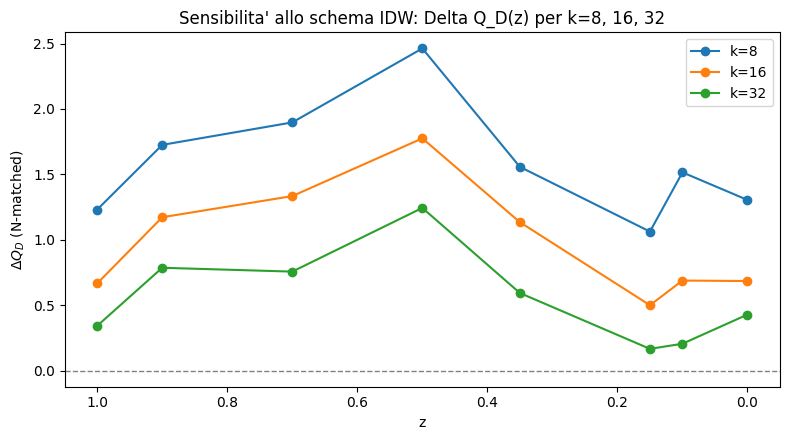

In [ ]:
# ============================================================
# TECHNICAL CHECK -- sensitivity to the IDW interpolation scheme
# Compares k=8, 16 (baseline used everywhere else), 32 -- same tracer
# subsample for every k, so it isolates only the effect of the
# interpolation, not sampling variability.
# ============================================================
for _name in ("flamingo_dir", "VARIANT_A", "VARIANT_B", "EPOCHS_EXTENDED", "BOX_SIDE",
              "GRID_1D", "N_GRID", "CELL_SIZE", "grid_tree",
              "observer_positions_R50", "DOMAIN_RADIUS_MPC_R50"):
    if _name not in dir():
        raise NameError(f"'{_name}' is not in memory -- rerun the notebook's base cells "
                         f"(make sure VARIANT_B points to NoCooling).")

K_LIST = [8, 16, 32]   # 16 is the value used throughout the main analysis

results_by_k = {k: [] for k in K_LIST}
for snapshot_file, z in EPOCHS_EXTENDED:
    print("=" * 70)
    print(f"EPOCH z={z} -- IDW sensitivity (k={K_LIST})")
    print("=" * 70)
    tr_A, vel_A, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_A["run_path"], snapshot_file, z)
    tr_B, vel_B, _ = load_tracers_and_velocities(flamingo_dir, VARIANT_B["run_path"], snapshot_file, z)
    target_n = min(len(tr_A), len(tr_B))
    tr_A, vel_A = subsample_to_match(tr_A, vel_A, target_n, seed=SEED)
    tr_B, vel_B = subsample_to_match(tr_B, vel_B, target_n, seed=SEED)
    print(f"  N-matched to {target_n} tracers (same subsample reused for all k)")

    for k in K_LIST:
        vx_A, vy_A, vz_A = build_velocity_field(tr_A, vel_A, GRID_1D, BOX_SIDE, N_GRID, k, verbose=False)
        th_A, s2_A = compute_theta_sigma2(vx_A.astype(np.float64), vy_A.astype(np.float64), vz_A.astype(np.float64), CELL_SIZE)
        vx_B, vy_B, vz_B = build_velocity_field(tr_B, vel_B, GRID_1D, BOX_SIDE, N_GRID, k, verbose=False)
        th_B, s2_B = compute_theta_sigma2(vx_B.astype(np.float64), vy_B.astype(np.float64), vz_B.astype(np.float64), CELL_SIZE)
        comparison = paired_QD_comparison(th_A, s2_A, th_B, s2_B, grid_tree, observer_positions_R50,
                                           DOMAIN_RADIUS_MPC_R50, label_A=VARIANT_A["label"],
                                           label_B=VARIANT_B["label"], verbose=False)
        results_by_k[k].append({"z": z, **comparison})
        print(f"    k={k:2d}: Delta={comparison['delta'].mean():.4f}  "
              f"CI95%=[{comparison['ci_lo']:.4f},{comparison['ci_hi']:.4f}]")

np.savez("/content/QD_idw_sensitivity.npz",
         z=[z for _, z in EPOCHS_EXTENDED],
         **{f"delta_k{k}": np.array([r["delta"] for r in results_by_k[k]]) for k in K_LIST})

# ---- summary table: how much Delta changes relative to the k=16 baseline ----
print()
print(f"{'z':>6s} {'Delta k=8':>10s} {'Delta k=16':>11s} {'Delta k=32':>11s} {'%var k=8':>10s} {'%var k=32':>10s}")
for i, (snapshot_file, z) in enumerate(EPOCHS_EXTENDED):
    d8 = results_by_k[8][i]["delta"].mean()
    d16 = results_by_k[16][i]["delta"].mean()
    d32 = results_by_k[32][i]["delta"].mean()
    pv8 = 100 * (d8 - d16) / abs(d16) if d16 != 0 else float('nan')
    pv32 = 100 * (d32 - d16) / abs(d16) if d16 != 0 else float('nan')
    print(f"{z:6.2f} {d8:10.4f} {d16:11.4f} {d32:11.4f} {pv8:10.1f} {pv32:10.1f}")

# ---- two-regime test for each k, to see whether the qualitative conclusion holds ----
from scipy.stats import norm

def weighted_regime_mean(results, z_lo, z_hi):
    sel = [r for r in results if z_hi <= r["z"] <= z_lo]
    means = np.array([r["delta"].mean() for r in sel])
    ses = np.array([(r["ci_hi"] - r["ci_lo"]) / (2 * 1.96) for r in sel])
    w = 1.0 / ses**2
    mean_w = float(np.sum(w * means) / np.sum(w))
    se_w = float(np.sqrt(1.0 / np.sum(w)))
    return mean_w, se_w

print()
print("REGIME COMPARISON for each k:")
for k in K_LIST:
    hi_mean, hi_se = weighted_regime_mean(results_by_k[k], 1.00, 0.35)
    lo_mean, lo_se = weighted_regime_mean(results_by_k[k], 0.15, 0.00)
    diff = hi_mean - lo_mean
    diff_se = np.sqrt(hi_se**2 + lo_se**2)
    z_score = diff / diff_se
    p_val = 2 * (1 - norm.cdf(abs(z_score)))
    print(f"  k={k:2d}: high={hi_mean:.3f}+/-{hi_se:.3f}  low={lo_mean:.3f}+/-{lo_se:.3f}  "
          f"diff={diff:.3f}+/-{diff_se:.3f}  p={p_val:.4f}")

# ---- plot ----
plt.figure(figsize=(8, 4.5))
for k in K_LIST:
    z_arr = np.array([r["z"] for r in results_by_k[k]])
    d_arr = np.array([r["delta"].mean() for r in results_by_k[k]])
    order = np.argsort(-z_arr)
    plt.plot(z_arr[order], d_arr[order], "o-", label=f"k={k}")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.gca().invert_xaxis()
plt.xlabel("z")
plt.ylabel(r"$\Delta Q_D$ (N-matched)")
plt.title("IDW scheme sensitivity: Delta Q_D(z) for k=8, 16, 32")
plt.legend()
plt.tight_layout()
plt.savefig("/content/idw_sensitivity.png", dpi=150)
plt.show()